# CIFAR-10 Autoencoder with GPU Acceleration - Final Project Report
**Group: 15**
| Mã số sinh viên | Họ tên              | 
| --------------- | ------------------- |
| 22120125        | Nguyễn Tấn Hưng     | 
| 22120144        | Mã Cát Huỳnh        |
| 22120147        | Bùi Trần Quang Khải |
---


# **1. Problem Description**


## **1.1 Problem Statement and Motivation**


Trong thời đại xã hội phát triển như vũ bão, AI dần khẳng định vị thế chiến lược trong đời sống và việc làm của vô số người. Nhằm ngày càng mở rộng và cải tiến công nghệ, học máy là một trong các kỹ thuật phổ biến nhất được áp dụng trong việc nghiên cứu và ứng dụng AI. Bên cạnh các đột phá, còn tồn tại nhiều hạn chế và thách thức trong việc áp dụng, triển khai phương pháp này.

Một thách thức đặc trưng của học máy là làm thế nào để tự động phát hiện các biểu diễn dữ liệu tốt, phản ánh cấu trúc tiềm ẩn của dữ liệu mà không phụ thuộc vào nhãn dán có sẵn. Vì suy cho cùng, các nhãn vẫn mang yếu tố chủ quan trong chúng, nên chắc chắn không thể khái quát hóa lên cao, mà chính sự tổng quát hóa mới giúp ta khám phá và thúc đẩy các giới hạn trong lĩnh vực nghiên cứu AI nói riêng, khoa học máy tính nói chung.

Do đó, nhóm em triển khai một hệ thống để học các đặc trưng một cách không giám sát dựa trên autoencoder, sử dụng dữ liệu mẫu là bài toán phân loại ảnh với bộ dữ liệu CIFAR-10, giúp đương đầu khó khăn phải tìm ra đặc trưng, các mẫu (pattern) của dữ liệu mà có tính tổng quát, khái quát.

Phương pháp học có giám sát truyền thống huấn luyện mô hình bằng các ví dụ có nhãn. Song, autoencoder cố gắng giải quyết vấn đề trên bằng cách cố gắng tìm ra các đặc trưng nổi bật nhất của tập dữ liệu mà không phụ thuộc vào nhãn. Bằng cách này, ta có thể phát hiện các đặc trưng bền vững và tổng quát hơn so với cách tiếp cận thông thường.

**Hệ thống có hai giai đoạn chính:**

**Giai đoạn 1: Học đặc trưng không giám sát:**

- Huấn luyện một autoencoder tích chập để trích xuất các đặc trưng ý nghĩa nhất từ ảnh.
- Bộ mã hóa (encoder) nén ảnh 32×32×3 thành vector đặc trưng 8.192 chiều. Không sử dụng nhãn trong giai đoạn huấn luyện này. Mạng học được các mẫu thị giác quan trọng (cạnh, kết cấu, hình dạng, v.v.).

**Giai đoạn 2: Phân loại có giám sát:**

- Trích xuất đặc trưng từ encoder đã huấn luyện cho toàn bộ tập ảnh.
- Huấn luyện bộ phân loại SVM trên các đặc trưng đã học với nhãn lớp.
- Đánh giá hiệu quả phân loại trên tập kiểm thử.


## **1.2 CIFAR-10 Dataset Overview**


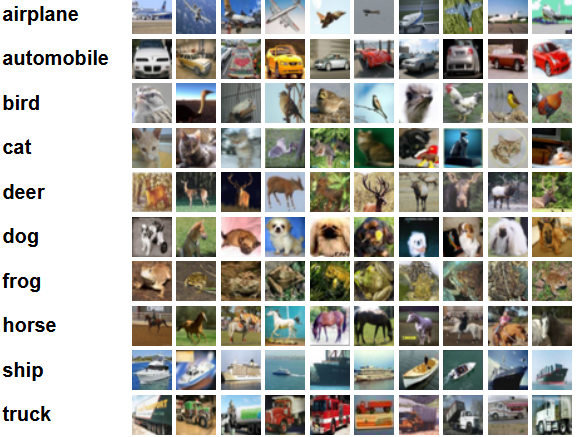

**Đặc điểm bộ dữ liệu:**
- **Kích thước ảnh:** 32×32 pixel (màu RGB)
- **Số lớp:** 10 loại (máy bay, ô tô, chim, mèo, nai, chó, ếch, ngựa, tàu thủy, xe tải)
- **Tập huấn luyện:** 50.000 ảnh (5.000 ảnh mỗi lớp)
- **Tập kiểm thử:** 10.000 ảnh (1.000 ảnh mỗi lớp)
- **Định dạng:** Nhóm sẽ làm với tệp nhị phân với giá trị pixel uint8 [0-255]
- **Cách tổ chức của các tập tin nhị phân**: Sẽ có 6 file nhị phân, lần lượt là `data_batch_1.bin` đến `data_batch_5.bin` và `test_batch.bin`, mỗi file có cấu trúc như sau:
    ```
    <1 x label><3072 x pixel>
    ...
    <1 x label><3072 x pixel>
    ```

**Các bước tiền xử lý:**
- Tải các tệp CIFAR-10 nhị phân theo yêu cầu, hoặc 5 batch huấn luyện cùng lúc, hoặc 1 batch kiểm thử
- Phân tích định dạng nhị phân: 1 byte nhãn + 3.072 byte (3x32×32) mỗi ảnh
- Giúp mô hình học nhanh và ổn định hơn, tránh hiện tượng gradient quá lớn hoặc quá nhỏ, đồng thời đảm bảo các giá trị đầu vào nằm trong cùng một khoảng, phù hợp với hàm kích hoạt ReLU, ta chuẩn hóa dữ liệu uint8 [0-255] sang float [0-1].
- Vì mỗi ảnh đã được lưu dưới dạng 1024 bytes đầu tiên là red channel, 1024 bytes tiếp theo là green channel và cuối cùng là blue. Ở mỗi channel dữ liệu được lưu theo row-major order. Dạng dữ liệu này đã phù với việc tính toán ma trận trong huấn luyện huẩn luyện mô hình (`tensor [NCHW]`) nên ta tiến hành load trực tiếp dữ liệu không cần chuyển đổi thứ tự.
- Đồng thời các hàm cơ bản của một dataloader cũng được triển khai như `shuffle` (xáo trộn vị trí các mẫu trong data), `load_batch` (chia data thành các batch để tối ưu training).

## **1.3 Autoencoder Architecture**


**Tổng quan kiến trúc của Autoencoder:**

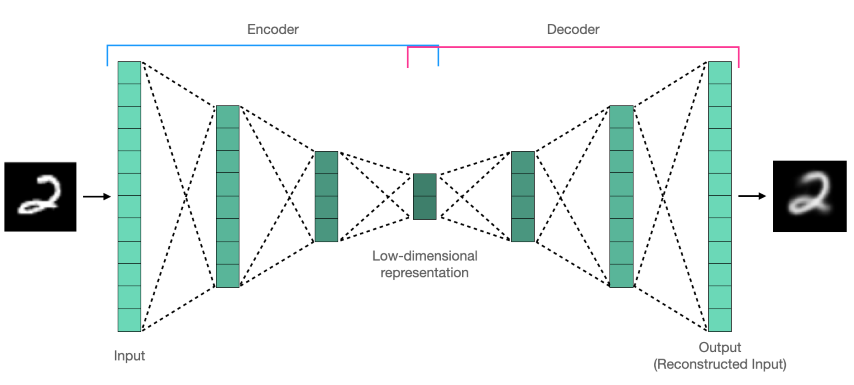


```
Input: (32×32×3) → Encoder → Latent: (8×8×128) = 8,192 đặc trưng → Decoder → Output: (32×32×3)
```

Autoencoder có 2 phần chính là **Encoder** và **Decoder**. Encoder được xem là phần để `mã hóa` dữ liệu (ở đây là ảnh) thành 1 dạng biểu diễn khác và dùng Decoder để `tái tạo` lại ảnh ban đầu từ dữ liệu đã được mã hóa.

    Dưới đây là cấu trúc chi tiết về dimension ở các layers của mô hình:

**Encoder (Downsampling):**
- Input: (32, 32, 3)
- Conv2D(256 filters, 3×3, padding=1) + ReLU → (32, 32, 256)
- MaxPool2D(2×2, stride=2) → (16, 16, 256)
- Conv2D(128 filters, 3×3, padding=1) + ReLU → (16, 16, 128)
- MaxPool2D(2×2, stride=2) → (8, 8, 128)
- **Latent representation: (8, 8, 128) = 8,192 dimensions**

**Decoder (Upsampling):**
- Latent: (8, 8, 128)
- Conv2D(128 filters, 3×3, padding=1) + ReLU → (8, 8, 128)
- Upsample2D(2×2) → (16, 16, 128)
- Conv2D(256 filters, 3×3, padding=1) + ReLU → (16, 16, 256)
- Upsample2D(2×2) → (32, 32, 256)
- Conv2D(3 filters, 3×3, padding=1) → (32, 32, 3)
- Output: (32, 32, 3)

    - Cấu trúc của encoder:
        - Các convolution layers, các filter được sử dụng để trích xuất, nhận biết các đặc trưng đặc biệt, quan trọng của bức ảnh.
        - Các maxpool layers dùng để giảm chiều của dữ liệu (ví dụ `[32, 32, 256]` → `[16, 16, 128]`). Thông qua quá trình này, số lượng phép tính mà mô hình phải thực hiện được giảm đi, đồng thời nó cũng bắt mô hình chỉ giữ lại các đặc trưng nổi bật, quan trọng nhất.
        > Thông qua quá trình này, chiều của dữ liệu được tăng lên, nhưng đồng thời các đặc trưng của ảnh được lưu ở lại nhiều hơn, điều rất quan trọng cho việc tái tạo lại ảnh.
    
    - Cấu trúc của latent space:
        - Ảnh input ban đầu có  $32 \times 32 \times 3 = 3,072$ giá trị nhưng khi biểu diễn ở latent space lại có tới $8 \times 8 \times 128 = 8,192$ giá trị.
        - Ở bước này dữ liệu không còn có thể xem như ảnh ban đầu. Thay vì biểu diễn ở các giá trị pixel rời rạc thì ở chiều dữ liệu cao hơn này, mỗi mẫu thể hiện được nhiều thông tin hơn ví dụ: "*có xuất hiện cánh máy bay*", "*có bánh xe tải*",...
    
    - Cấu trúc của decoder:
        - Khối decoder được dùng để tái tạo lại ảnh ban đầu, ta có thể nhận thấy cấu trúc của khối này như đối xứng so với encoder. Ngược lại với maxpool ta dùng Upsample, thay đổi số filter của convolution để tái tạo lại chiều cấu trúc ảnh ban đầu.




## **1.4 Objectives**



**Hiệu năng:**
- Thời gian huấn luyện autoencoder cho 50.000 ảnh huấn luyện cho 1 epoch: < 20 phút
- Thời gian trích xuất đặc trưng (50.000 ảnh huấn luyện + 10.000 ảnh test): < 20 giây
- Độ chính xác phân loại kiểm thử: 60-65%
- Thời gian huấn luyện của GPU nhanh CPU 20 lần.

**Kiến thức và trải nghiệm:**
- Hiện thực các phép toán deep learning từ đầu bằng C++/CUDA
- Thành thạo hơn về lập trình GPU: kernel, quản lý bộ nhớ, tối ưu hóa
- Hiểu và cài đặt được kiến trúc autoencoder ở mức độ cơ bản
- Biết quan sát và tối ưu hóa bằng cách áp dụng các phương pháp song song hóa lên GPU
- Biết tư duy, tìm tòi để cải tiến các phiên bản chạy trên GPU một cách có hệ thống

**Tiêu chí thành công:**
- Pipeline hoàn chỉnh, có thể xử lí từ ảnh gốc đến ra kết quả phân loại cho phiên bản cài bằng CPU, GPU
- Các sự cài đặt của module, layers, ... đều vượt qua unit test kiểm thử, đảm bảo tính đúng đắn
- Cài đặt đúng, có kiểm chứng đối chiếu với phiên bản CPU sơ khai
- Đo lường được mức độ tăng tốc thông qua tối ưu GPU
- Độ chính xác phân loại đạt tối thiểu 60-65%
- Có ghi chú tài liệu rõ ràng về các chiến lược tối ưu và kết quả tương ứng


# **2. Implementation phases**

## **2.1 CPU baseline implementation**


### **2.1.1 Objectives**

- Thiết lập phiên bản cơ sở trên CPU cho toàn bộ kiến trúc, từ học không giám sát đến phân loại có giám sát: xác thực tính đúng đắn và đo lường các chỉ số hiệu năng cơ bản: thời gian, độ mất mát, mức sử dụng bộ nhớ  
- Cung cấp một phiên bản tham chiếu để kiểm chứng tính chính xác của các phiên bản tối ưu hóa  
- Làm rõ các nút thắt hiệu năng (performance bottlenecks), xác định tiềm năng cho việc tối ưu hóa cho các giai đoạn tiếp theo

### **2.1.2 Implementation details**

- Data pipeline
    - Nạp trực tiếp các tệp nhị phân vào các mảng float cấp phát động
    - Duyệt tuần tự theo từng byte, từng batch, trích xuất giá trị pixel và nhân với NORMALIZATION_FACTOR (1/255)
    - Sử dụng biến random kiểu `std::mt19937` (The classic Mersenne Twister) cho việc xáo trộn (shuffle)
- Cài đặt các layers

    **1. Conv2D**: Thực hiện phép tích chập 2D với nhiều channel, hỗ trợ padding, stride, khởi tạo trọng số theo phương pháp Xavier/He.
    - Cài đặt:
        - Forward: Lặp qua batch, output channel, spatial, input channel, kernel để tính tổng có cộng bias. Xử lý padding bằng kiểm tra chỉ số.
        - Backward: Tính gradient cho input, trọng số, bias bằng cách lặp tương tự, cộng dồn gradient theo công thức chain rule.
        - Cập nhật trọng số: SGD, với weight -= lr * grad.
        - Trọng số và bias lưu dưới dạng vector 1 chiều, ánh xạ chỉ số thủ công (manual - tự tính để chuyển từ chỉ số 4 chiều sang chỉ số 1 chiều)

    **2. ReLU**: Hàm gán 0 cho giá trị âm
    - Cài đặt:
        - Forward: Duyệt toàn bộ tensor, gán max(0, x).
        - Backward: Gradient truyền qua nếu input > 0, ngược lại bằng 0.

    **3. MaxPool**: Lấy giá trị lớn nhất trong mỗi cửa sổ pooling (thường 2x2), giảm chiều dữ liệu.
    - Cài đặt:
        - Forward: Duyệt từng cửa sổ, tìm giá trị lớn nhất và lưu lại chỉ số (index) để dùng cho backward.
        - Backward: Gradient chỉ truyền về vị trí có giá trị lớn nhất, các vị trí còn lại bằng 0.

    **4. Upsample**: Tăng kích thước bằng phép lặp lại giá trị (nearest neighbor).
    - Cài đặt:
        - Forward: Mỗi pixel output lấy giá trị từ pixel input gần nhất (theo scale).
        - Backward: Gradient cộng dồn về pixel input tương ứng từ nhiều pixel output.
        - Forward: Mỗi pixel output lấy giá trị từ pixel input gần nhất (theo scale).
        - Backward: Gradient cộng dồn về pixel input tương ứng.

- Training loop
    - Đầu tiên, tải dữ liệu lên, khởi tạo theo dõi thông số về bộ nhớ, thời gian
    - Thực hiện chạy với 500 ảnh và 2 epochs
    - Chạy theo epoch, trong mỗi epoch sẽ duyệt qua từng batch để lần lượt đưa dữ liệu vào autoencoder (forward và backward pass) rồi ghi nhận, hiển thị các thông tin về loss, thời gian, bộ nhớ
    - Mỗi epoch sẽ lưu lại thông số ảnh gốc và ảnh tái tạo (chạy qua forward pass của autoencoder), để về sau trực quan hóa

- Việc huấn luyện autoencoder bao gồm 500 ảnh đầu tiên của tập huấn luyện, 2 epochs. Sau đó, autoencoder đó được dùng để extract features, bao gồm 500 ảnh đầu tiên từ tập huấn luyện và 500 ảnh đầu của tập kiểm thử.
- Việc thực hiện SVM cũng bao gồm chạy classification trên 500 ảnh đầu của tập huấn luyện và 500 ảnh đầu của tập kiểm thử.
- Luôn sử dụng 500 ảnh đầu tiên của tập huấn luyện và tập kiểm thử trong bản cài đặt CPU.


- Key code snippets
- Convolution function signature:
```cpp
        Conv2DCPU(int in_channels_num, int out_channels_num, int kernel_size, int stride = 1, int padding = 0);
        Tensor forward(const Tensor &input);
        Tensor backward(const Tensor &input);
        void set_weight(const std::vector<float> &weights, const std::vector<float> &bias);
        void get_weights(std::vector<float> &weights, std::vector<float> &bias) const;
        void get_gradients(std::vector<float> &grad_w, std::vector<float> &grad_b);
        void update_weights(float learning_rate);
```

- Main loop structure:
```cpp
        std::vector<float> losses;
        std::vector<double> epoch_times;
        std::vector<size_t> epoch_memory;
        auto train_start = std::chrono::high_resolution_clock::now();

        for (int ep = 0; ep < SUB_EPOCHS; ++ep)
        {

            auto ep_start = std::chrono::high_resolution_clock::now();
            loader.shuffle();

            int batches = TRAIN_IMAGES / BATCH_SIZE;
            double ep_loss = 0.0;

            for (int b = 0; b < batches; ++b)
            {
                float *batch_data = loader.get_batch(BATCH_SIZE);

                Tensor batch_tensor({BATCH_SIZE, 3, 32, 32}, false);
                std::memcpy(batch_tensor.raw_data(), batch_data, BATCH_SIZE * 3 * 32 * 32 * sizeof(float));

                // Forward pass
                Tensor output = model.forward(batch_tensor);
                float batch_loss = model.compute_loss(output, batch_tensor);
                ep_loss += batch_loss;

                // Backward pass
                model.backward(batch_tensor, LEARNING_RATE);

                // Display batch loss
                // ...
                
            }


            // process time, memory...

            // print out info...

            // Save original and reconstruction images

            float *sample_data = loader.get_batch(BATCH_SIZE);
            Tensor sample_tensor({BATCH_SIZE, 3, 32, 32}, false);
            std::memcpy(sample_tensor.raw_data(), sample_data, BATCH_SIZE * 3 * 32 * 32 * sizeof(float));

            Tensor reconstructed = model.forward(sample_tensor);

            ImageUtils::save_reconstruction_samples(
                sample_tensor, reconstructed,
                std::string(MODEL_SAVE_DIR), "epoch_" + std::to_string(ep + 1), 1);
        }
```


### **2.1.3 Results**


- Thời gian huấn luyện:
    - Epoch 1: 2067.75s
    - Epoch 2: 1859.52s
    - Tổng: 3927.27s (~65-66 phút)
- Final reconstruction loss: 0.141507
- Mức độ sử dụng bộ nhớ cao nhất:
    - Epoch 1: 222.79 MB
    - Epoch 2: 217.04 MB
- So ảnh gốc với ảnh tái tạo:

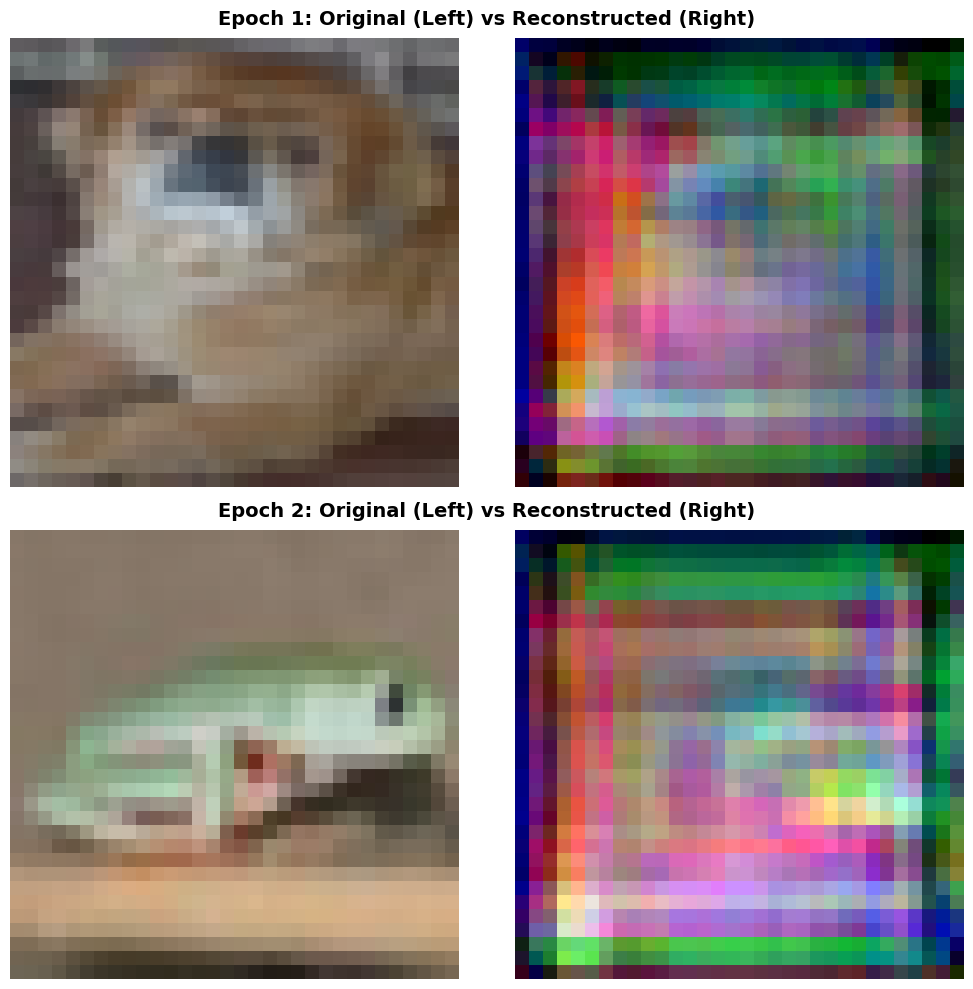

### **2.1.4 Key Takeaways**



- Nhận xét về thuật toán
    - Thuật toán bao gồm hai bước lớn, huấn luyện autoencoder, trích xuất đặc trưng và huấn luyện và chạy SVM
    
    - Hai bước trên cần sự tuần tự thực hiện, tuy nhiên, trong mỗi bước đều có yếu tố có thể song song hóa vì xử lí theo từng ảnh input, mà các ảnh này không liên quan đến nhau. Trong mỗi ảnh, các pixel cũng có tính chất độc lập với nhau.
    
    - Huấn luyện autoencoder tốn nhiều thời gian nhất, nhưng cũng ảnh hưởng lớn nhất đến độ chính xác toàn bộ pipeline

- Những phát hiện định hướng cho bản GPU
    
    - Việc thực hiện tích chập có thể song song hóa vì thao tác trên mỗi output pixel không phụ thuộc nhau
    
    - Có nhiều ảnh nhưng các ảnh không liên quan đến nhau, và các pixel trên mỗi ảnh cũng độc lập lẫn nhau nên toàn bộ thao tác tương tác, xử lí trên ảnh đều song song hóa được

## **2.2 GPU Naive Implementation**

### **2.2.1 Objectives**

Để cải thiện thời gian thực hiện huấn luyện, tiếp theo ta tiến hành chuyển đổi mã nguồn từ CPU sang GPU với các phương thức song song hóa cơ bản. Mục tiêu của phiên bản mã nguồn GPU đơn giản này là giúp xác định hướng đi đúng ban đầu, xác thực tính đúng đắn cho các thuật toán ở phiên bản song song nhằm phục vụ cho những lần cải tiến tiếp theo.

### **2.2.2 Implementation details**

**Ý tưởng chính:**

- Mỗi thread đảm nhận tính toán cho một phần tử đầu ra tại vị trí cụ thể (h, w) của một ảnh (n) và một kênh (c).
- Tạo cấu trúc dữ liệu tensor để lưu trữ các thông tin của dữ liệu (batch, channel, height, width) của các mẫu nhằm phụ vụ cho việc tính toán dựa trên chỉ số ma trận.
- Về cơ bản, mỗi grid có 3 chiều, ta sẽ sử dụng chúng để đại diện cho các chiều dữ liệu kiểu tensor.
**Cài đặt các layers:**
1. **Convolution Kernel:**
   - Mỗi thread đảm nhận tính toán cho một pixel đầu ra (output pixel) tại vị trí (n, c_out, h_out, w_out).
   - Thread xác định vị trí output dựa trên blockIdx và threadIdx.
   - Trong mỗi thread, thực hiện vòng lặp qua toàn bộ kernel (kích thước kH × kW) và các kênh đầu vào (C_in) để tính tổng tích chập.
   - Sử dụng bộ nhớ toàn cục (global memory) để đọc input, weights, bias và ghi output.
Kiểm tra điều kiện padding để tránh truy cập ngoài biên.

* kernel
```cpp
   __global__ void conv2d_forward_kernel_naive(
    const float* __restrict__ input,
    const float* __restrict__ weights,
    const float* __restrict__ bias,
    float* __restrict__ output,
    int N, int C_in, int H_in, int W_in,
    int C_out, int H_out, int W_out,
    int kH, int kW,
    int stride, int padding,
    bool apply_relu) {
      int n = blockIdx.x;
      int c_out = blockIdx.y;
      int hw = blockIdx.z * blockDim.x + threadIdx.x;
      
      int h_out = hw / W_out;
      int w_out = hw % W_out;
      
      if (n >= N || c_out >= C_out || h_out >= H_out || w_out >= W_out) return;
      
      float sum = 0.0f;
      
      for (int c_in = 0; c_in < C_in; c_in++)        // iterate over input channels
         for (int kh = 0; kh < kH; kh++)            // iterate over kernel height
            for (int kw = 0; kw < kW; kw++)        // iterate over kernel width
                  ......

      sum += bias[c_out];
    }

```

* Khi gọi hàm
```cpp
   int threads = 256;
   int blocks_z = (H_out * W_out + threads - 1) / threads;
   dim3 grid(N, C_out, blocks_z);
   dim3 block(threads);

   conv2d_forward_kernel_naive<<<grid, block>>>(
      input.d_data, weights.d_weights, weights.d_bias, output.d_data,
      N, C_in, H_in, W_in, C_out, H_out, W_out,
      kernel_h, kernel_w, stride, padding, apply_relu
   );

```

2. **ReLU Kernel:**
   - Mỗi thread xử lý một phần tử duy nhất trong tensor. Cách thực hiện tính toán vẫn như trên phiên bản CPU.

3. **MaxPooling Kernel:**
   - Tương tự như ReLu Kernel, mỗi thread chỉ thực hiện tính toán trên một phần tử đầu ra.
   - Thread xác định vị trí output (n, c, h_out, w_out).
   - Duyệt qua cửa sổ pooling (thường 2×2), tìm giá trị lớn nhất và lưu lại chỉ số (index) để dùng cho backward.

4. **Upsampling Kernel:**
   - Thread xác định vị trí output (n, c, h_out, w_out).
   - Tính toán vị trí tương ứng trên input (nearest neighbor) và gán giá trị.

**Memory Management:**
- Sử dụng cudaMalloc để cấp phát bộ nhớ cho weights, activations, gradients trên device.
- Sử dụng cudaMemcpy để truyền dữ liệu từ host sang device (input, weights, labels) và ngược lại (output, loss).

### **2.2.3 Results**


Thông tin tổng quan

| Metric                    | Value      |
|---------------------------|------------|
| Total training time       | 9213.01 s  |
| Average time per epoch    | 460.65 s   |
| GPU memory usage          | 390 MB     |

Bảng so sánh thời gian chạy của CPU và GPU Naive

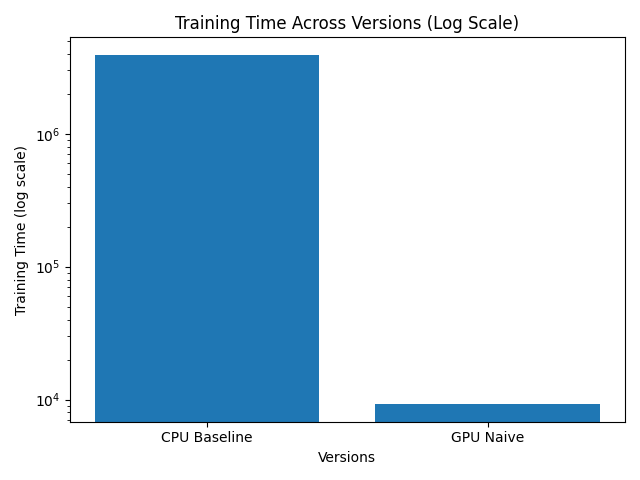

Line chart so sánh thời gian chạy tích lũy so với CPU của GPU Naive


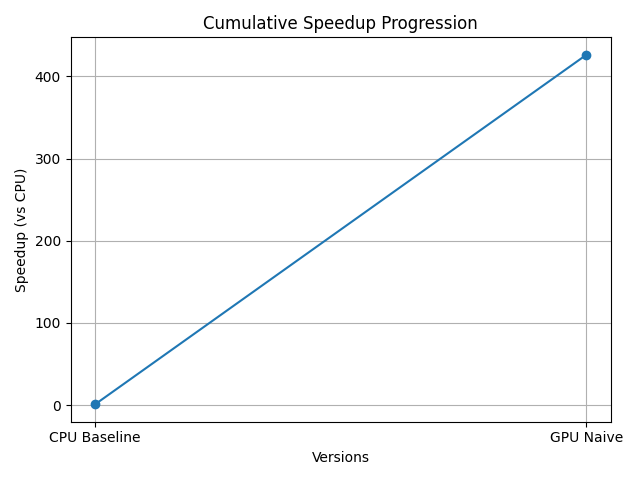


### Nhận xét
- Kết quả: Thời gian giảm từ khoảng 3.9 triệu giây xuống còn 9,213 giây.
- Speedup: Đạt 426.30 lần.
- Nhận xét: Đây là bước nhảy vọt lớn nhất về hiệu năng. Việc chuyển đổi từ xử lý tuần tự trên CPU sang xử lý song song cơ bản trên GPU đã giải quyết được nút thắt cổ chai chính trong việc tính toán trên tập dữ liệu lớn.
- Kỹ thuật song song hóa đã biến một tác vụ bất khả thi trên CPU (mất hàng tháng) thành một tác vụ có thể hoàn thành trong 2,5 giờ.

### **2.2.4 Profiling Analysis**


Hình ảnh Profiling của GPU Naive


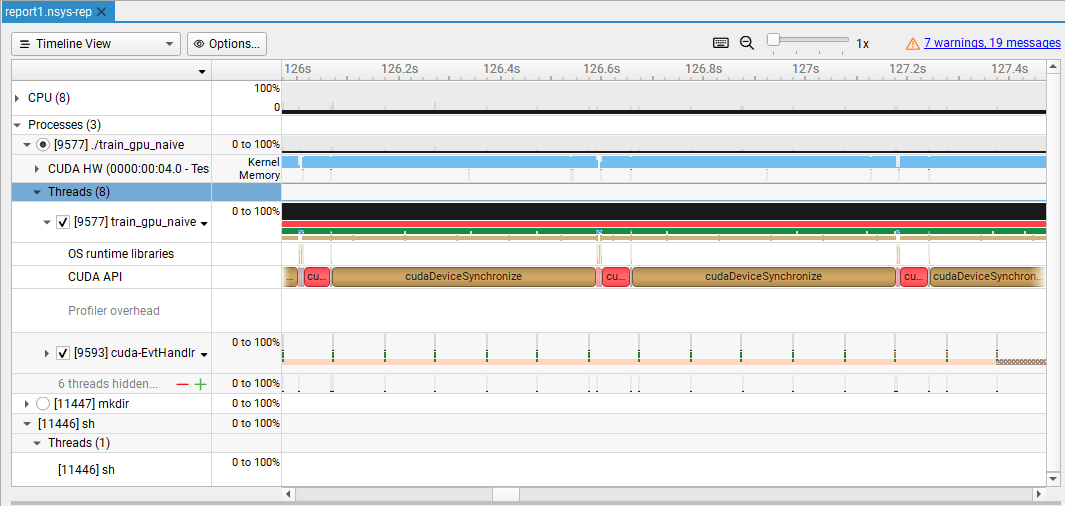



Dựa vào kết quả profiling xuất ra `naive.txt`, ta có:

**CUDA API Summary (cuda_api_sum):**

| Time (%) | Total Time (ns) | Name                                   |
|----------|-----------------|----------------------------------------|
| 88.9     | 404017436921    | cudaDeviceSynchronize                  |
| 9.7      | 44096619630     | cudaMemcpy                             |
| 0.8      | 3651636133      | cudaFree                               |
| 0.2      | 943011919       | cudaMalloc                             |
| 0.2      | 803852732       | cudaHostAlloc                          |
| 0.2      | 777431142       | cudaFreeHost                           |
| 0.0      | 218249382       | cudaLaunchKernel                       |
| 0.0      | 23650723        | cudaMemset                             |
| 0.0      | 22966488        | cudaMemcpyAsync                        |
| 0.0      | 1315318         | cudaEventCreate                        |
| 0.0      | 92333           | cudaGetDeviceProperties_v2_v12000      |
| 0.0      | 66552           | cudaMemGetInfo                         |
| 0.0      | 29686           | cudaEventRecord                        |
| 0.0      | 5430            | cudaEventSynchronize                   |
| 0.0      | 4627            | cudaEventDestroy                       |
| 0.0      | 1555            | cuModuleGetLoadingMode                 |

**CUDA GPU Kernel Summary (cuda_gpu_kern_sum):**

| Time (%) | Total Time (ns) | Name                                                                                           |
|----------|-----------------|------------------------------------------------------------------------------------------------|
| 45.5     | 204042641337    | conv2d_backward_input_kernel_naive(const float *, const float *, float *, int, int, int, int, int, … |
| 40.7     | 182580449583    | conv2d_backward_weights_kernel_naive(const float *, const float *, float *, int, int, int, int, int, … |
| 9.6      | 43150397847     | conv2d_forward_kernel_naive(const float *, const float *, const float *, float *, int, int, int, in… |
| 3.8      | 16857542283     | conv2d_backward_bias_kernel_naive(const float *, float *, int, int, int, int)                  |
| 0.1      | 543170243       | upsample2d_forward_kernel_naive(const float *, float *, int, int, int, int, int, int, int)     |
| 0.1      | 509334140       | maxpool2d_backward_kernel_naive(const float *, const int *, float *, int, int, int, int)       |
| 0.1      | 393844812       | maxpool2d_forward_kernel_naive(const float *, float *, int *, int, int, int, int, int, int, int, in… |
| 0.1      | 336316651       | upsample2d_backward_kernel_naive(const float *, float *, int, int, int, int, int, int, int)    |
| 0.0      | 32497398        | sgd_update_kernel_naive(float *, const float *, float, int)                                    |
| 0.0      | 13338517        | mse_loss_forward_kernel_naive(const float *, const float *, float *, int)                      |
| 0.0      | 5416769         | mse_loss_backward_kernel_naive(const float *, const float *, float *, int, float)              |

- Dựa vào các thông số trên, có thể thấy phiên bản này hai hàm kernel chiếm phần lớn thời gian nhất lần lượt là conv2d_backward_input_kernel_naive (45.5%) và conv2d_backward_weights_kernel_naive (40.7%). Với câu lệnh `ncu --set basic ./build/train_gpu_naive`, ta có được báo cáo chi tiết cho các hàm kernel, nhưng ta sẽ tập trung vào thông số hai hàm trên (chiếm hơn 85% thời gian).

- Ta có thông số của hàm conv2d_backward_input_kernel_naive (nhiều lần, với kích cỡ layer khác nhau)

| Chỉ số                       | (64, 256, 4)x(256, 1, 1) | (64, 128, 1)x(256, 1, 1) | (64, 128, 1)x(256, 1, 1) (2) | (64, 256, 1)x(256, 1, 1) | (64, 3, 4)x(256, 1, 1) | Trung bình |
| :--------------------------- | :----------------------- | :----------------------- | :--------------------------- | :----------------------- | :--------------------- | :------ |
| Memory Throughput            | 12.34 %                  | 12.19 %                  | 10.90 %                      | 12.22 %                  | 11.23 %                | 11.78 % |
| DRAM Throughput              | 1.31 %                   | 6.07 %                   | 0.07 %                       | 5.91 %                   | 5.16 %                 | 3.70 %  |
| Compute (SM) Throughput      | 76.15 %                  | 75.48 %                  | 67.67 %                      | 75.64 %                  | 70.35 %                | 73.06 % |
| Achieved Occupancy           | 96.76 %                  | 98.75 %                  | 75.16 %                      | 98.40 %                  | 93.01 %                | 92.42 % |
| Achieved Active Warps Per SM | 30.96                    | 31.60                    | 24.05                        | 31.49                    | 29.76                  | 29.57   |

- Ta có thông số của hàm conv2d_backward_weights_kernel_naive (nhiều lần, với kích cỡ layer khác nhau)

| Chỉ số                       | (3, 256, 1)x(256, 1, 1) | (256, 128, 1)x(256, 1, 1) | (1, 1, 1)x(256, 1, 1) | (128, 128, 1)x(256, 1, 1) | (128, 256, 1)x(256, 1, 1) | (256, 3, 1)x(256, 1, 1) | (3, 256, 1)x(256, 1, 1) (2) | Trung bình |
| :--------------------------- | :---------------------- | :------------------------ | :-------------------- | :------------------------ | :------------------------ | :---------------------- | :-------------------------- | :------ |
| Memory Throughput            | 26.11 %                 | 61.87 %                   | 2.31 %                | 65.78 %                   | 61.80 %                   | 20.42 %                 | 26.71 %                     | 37.86 % |
| DRAM Throughput              | 1.38 %                  | 9.05 %                    | 1.41 %                | 0.19 %                    | 8.81 %                    | 3.65 %                  | 1.38 %                      | 3.70 %  |
| Compute (SM) Throughput      | 26.11 %                 | 61.87 %                   | 0.14 %                | 65.78 %                   | 61.80 %                   | 20.42 %                 | 26.71 %                     | 37.55 % |
| Achieved Occupancy           | 18.59 %                 | 47.98 %                   | 25.05 %               | 46.33 %                   | 47.93 %                   | 15.65 %                 | 17.41 %                     | 31.28 % |
| Achieved Active Warps Per SM | 5.95                    | 15.35                     | 8.02                  | 14.83                     | 15.34                     | 5.01                    | 5.57                        | 10.01   |

- **Mức độ tận dụng băng thông bộ nhớ và tính toán:**
  - Thực hiện truy cập trực tiếp vào Global Memory cho mỗi thao tác đọc input, bias trong các vòng lặp lồng nhau, khiến việc truy xuất rất chậm, ảnh hưởng xấu đến tốc độ huấn luyện toàn bộ pipeline.
  - Kernel conv2d_backward_input_kernel_naive thể hiện rõ đặc tính bị giới hạn bởi năng lực tính toán (Compute Bound) khi có chỉ số Compute (SM) Throughput cao trong khi Memory Throughput và DRAM Throughput rất thấp. Kernel có Achieved Occupancy đạt mức rất cao chứng tỏ GPU duy trì được số lượng lớn các warp hoạt động.
  - Kernel conv2d_backward_weights_kernel_naive lại có Achieved Occupancy, Compute Throughput và Memory Throughput đều chỉ ở mức thấp, cho thấy phần cứng chưa khai thác được tối đa việc sử dụng các warp, năng lực tính toán và băng thông.

- **Nhận diện các nút thắt hiệu năng ban đầu:**
  - conv2d_backward_input_kernel_naive là nút thắt lớn nhất, việc tính toán đòi hỏi lượng lớn truy cập bộ nhớ. Điều này đồng nghĩa phải truy cập Global Memory nhiều lần và làm chậm toàn bộ pipeline
  
  - Việc gọi cudaDeviceSynchronize nhiều lần (88.9%) chứng tỏ còn chưa tận dụng việc đa luồng, hoặc còn tồn tại nhiều lời gọi cuda API mà khiến các luồng không thực hiện song song được.



### **2.2.5 Key Takeaways**



- **Tốc độ thực thi của các kernel**
  - Convolution kernels chậm hơn rất nhiều so với kỳ vọng lý thuyết nếu chỉ nhìn vào số lượng phép tính, nguyên nhân chính là do độ trễ bộ nhớ.
  
  - Các layer như ReLU, MaxPool, Upsample chạy rất nhanh và chiếm thời gian không đáng kể, cho thấy việc tối ưu hóa nên tập trung phần lớn vào convolution.

- **Các vấn đề cần tối ưu:**
  - Sử dụng Shared Memory: load các block dữ liệu (input tile, weight tile) vào Shared Memory để giảm số lần truy cập Global Memory.

  - Sử dụng Constant Memory cho các mảng nhỏ như bias, cũng nhằm mục đích hạn chế truy cập vào Global Memory.

- **Giới hạn băng thông và giới hạn tính toán:**
  - Các kernels đều bị giới hạn bởi memory bound vì bị ảnh hưởng bởi truy xuất vào Global Memory nhiều lần, trong đó các hàm convolution kernels là bị ảnh hưởng nặng nhất vì cần truy cập các pixel ở ảnh input liên tục trong lúc thực hiện tính toán.

  - Các kernels nhìn chung đều có thao tác tính toán đơn giản, chưa bị giới hạn bởi tính toán.

## **2.3 GPU Optimized Implementation - Version 1**


### **2.3.1 Optimization Focus**


Nhận thấy vấn đề khi thực hiện GPU ở phiên bản trước là lượt truy cập Global memory rất nhiều ở các kernel. Phiên bản tối ưu này tập trung cải thiện vấn đề này bằng cách sử dụng các loại memory khác như Shared memory và Constant memory.



### **2.3.2 Targets**

- Giải quyết vấn đề "memory bound" của phiên bản Naive, nơi các luồng phải đọc đi đọc lại cùng một dữ liệu từ Global Memory.

- Shared Memory Tiling: Giảm thiểu độ trễ truy cập bộ nhớ toàn cục (Global Memory) bằng cách đưa các vùng dữ liệu input lặp lại nhiều lần vào bộ nhớ chia sẻ (Shared Memory) tốc độ cao.

- Constant Memory: Sử dụng bộ nhớ hằng số (Constant Memory) cho các tham số ít thay đổi và kích thước nhỏ như bias để tận dụng bộ nhớ cache chuyên dụng.

- Mong muốn tăng tốc độ thực thi của kernel convolution (forward pass) do giảm băng thông bộ nhớ yêu cầu.



### **2.3.3 Implementation Details**


**Các phương pháp cải tiến được áp dụng:**

1.  **Shared Memory Tiling cho Convolution Forward:**
    - **Kỹ thuật:** Chia ảnh đầu vào và output thành các "tile" nhỏ (kích thước 16x16). Mỗi block CUDA sẽ chịu trách nhiệm tính toán một tile output.
    
    - **Cách thức:** Các luồng trong block hợp tác (cooperative loading) để tải input tile tương ứng vào Shared Memory.
    
    - **Xử lý Halo:** Vì kernel convolution (3x3) cần thông tin từ các pixel lân cận, nên khi load vào Shared Memory, ta cần load thêm vùng biên (halo/padding) xung quanh tile chính. Block size được tăng lên (TILE_W + 2, TILE_H + 2) để xử lý việc này.
    
    - **Lợi ích:** Dữ liệu input trong Shared Memory được truy cập nhanh hơn rất nhiều so với Global Memory, và được tái sử dụng bởi nhiều luồng trong block khi tính toán tích chập.

2.  **Constant Memory cho Bias:**
    
    - **Kỹ thuật:** Khai báo mảng `__constant__ float c_bias[256]` để lưu trữ bias.
    
    - **Lợi ích:** Constant Memory có cơ chế caching riêng, rất hiệu quả khi tất cả các luồng trong một warp cùng đọc một địa chỉ bộ nhớ (điều này xảy ra khi cộng bias cho cùng một channel).
    
    - Lý do ta có thể cập nhật bias trong khi nó lưu trữ trong constant memory là bởi vì bias được cập nhật trong quá trình tính toán được lưu ở struct `GPUConvWeightsOpt` (Global memory) sau đó được copy sang constant memory bằng hàm `cudaMemcpySymbol` khi thực hiện forward.

3. **Tạo và sử dụng struct Memory pool**
    - Mục tiêu của struct này là cấp phát trước tất cả các buffer cần thiết (giá trị kích hoạt, gradient, chỉ số pooling) cho toàn bộ quá trình forward và backward của mô hình, giúp giảm chi phí cấp phát động và phân mảnh bộ nhớ.
    
    - Cung cấp các biến act1, act2, ..., grad_out, grad1,... cho từng kết quả trung gian và gradient của mỗi lớp, giúp dễ dàng truy cập và tái sử dụng bộ nhớ cho từng giai đoạn tính toán.
  
    - Quản lý chỉ số pooling (pool1_idx, pool2_idx) cho các lớp maxpool, cần thiết cho quá trình backward.


```cpp
// Constant memory for biases
__constant__ float c_bias[256];

// Shared Memory Tiling Kernel
__global__ void conv2d_forward_tiled_kernel(...) {
    // Shared memory for input tile (with halo for 3x3 kernel)
    __shared__ float s_input[TILE_H + 2][TILE_W + 2];
    // ... (Index calculation)

    // Cooperative loading of input tile into shared memory
    // Load main tile element + halo elements
    // ...
    __syncthreads();

    // Convolution from shared memory
    if (h_out < H_out && w_out < W_out) {
        for (int kh = 0; kh < KERNEL_SIZE; kh++) {
            for (int kw = 0; kw < KERNEL_SIZE; kw++) {
                // Access s_input instead of global input
                sum += s_input[ty + kh][tx + kw] * weights[...];
            }
        }
    }
}
```

```cpp
// Memory pool struct
struct GPUMemoryPool {
    // Forward activations
    GPUTensorOpt act1, act2, act3, act4, act5, act6, act7, act8, output;
    // Backward gradients  
    GPUTensorOpt grad_out, grad8, grad7, grad6, grad5, grad4, grad3, grad2, grad1, grad_in;
    // Pooling indices
    int* pool1_idx;
    int* pool2_idx;
    
    int batch_size;
    bool allocated;

//.....
}

```

### **2.3.4 Results**


Thông số tổng quát

| Metric                    | Value      |
|---------------------------|------------|
| Total training time       | 3706.07 s |
| Average time per epoch    | 185.30s  |
| GPU memory usage          | 490 MB     |


Bảng so sánh với baseline

_Vì phiên bản CPU chạy 500 ảnh và 2 epoch và nên chúng em lấy trung bình và nhân lên 100 lần để đủ kích thước dataset và 20 lần đủ đủ số thời gian chạy epochs_

| Phase        | Training Time (s) | Speedup (vs CPU) | Incremental Speedup | Memory Usage (MB) | Key Optimization        |
|--------------|-------------------|------------------|---------------------|-------------------|-------------------------|
| CPU Baseline | 3,927,270         | 1.00×            | –                   | 1.0               | –                       |
| GPU Naive    | 9,213.01          | 426.30×          | 426.30×             | 308               | Basic Parallelization   |
| GPU Opt v1   | 3,706.07          | 1,059.80×        | 2.49×               | 490               | Shared memory           |


Bảng so sánh thời gian chạy

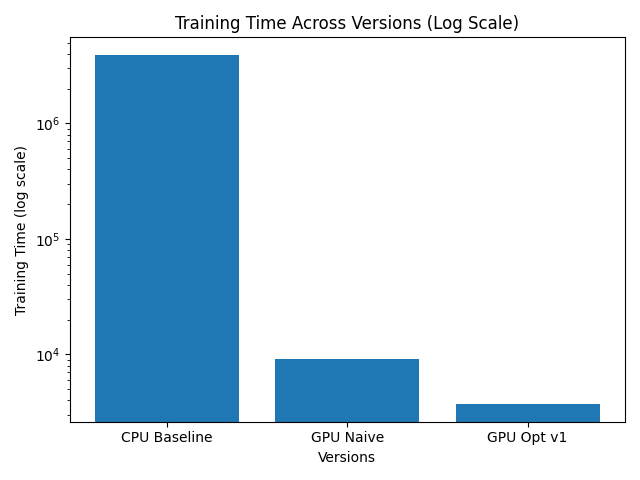

Line chart so sánh thời gian chạy tích lũy so với CPU


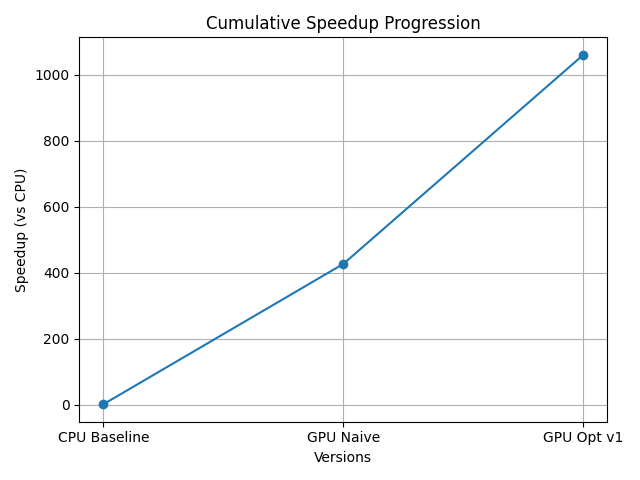

### Nhận xét
#### Tổng quan kết quả
Phiên bản sử dụng Shared Memory (GPU Opt v1) đã đạt được hiệu suất vượt trội so với các phiên bản trước:
- Tổng thời gian huấn luyện: ~1 giờ (3,706.07 giây).
- Thời gian trung bình mỗi epoch: 185.30 giây.
- Tăng tốc nhanh hơn khoảng 1,060 lần so với CPU Baseline.

#### So sánh với phiên bản trước từ GPU Naive sang GPU Opt v1
- Kết quả: Thời gian giảm tiếp từ 9,213 giây xuống 3,706 giây.
- Incremental speedup: Tăng tốc thêm 2.49 lần so với bản GPU Naive.
- Nhận xét: Việc tận dụng Shared Memory giúp giảm độ trễ truy cập bộ nhớ toàn cục. Mặc dù mức tăng tốc 2.49 lần không lớn như bước đầu tiên nhưng đây là mức tối ưu hóa có ý nghĩa giúp giảm thời gian chạy thực tế từ khoảng 2.5 giờ xuống còn 1 giờ.

#### Phân tích biểu đồ
- Biểu đồ bar chart training time:
  - Thấy được sự chênh lệch quá lớn giữa CPU và GPU
  - Cột đầu tiên (CPU Baseline) cao vượt trội cho thấy việc huấn luyện mô hình này hoàn toàn bất khả thi trên CPU (ước tính mất khoảng 45 ngày).
  - Hai cột sau cho thấy xu hướng giảm dần đều.

- Biểu đồ cumulative speedup srogression:
  - Đường biểu diễn dốc đứng thể hiện mức tăng tốc lũy tiến, độ dốc lớn.
  - Điểm cuối cùng đạt mốc hơn 1000 lần và khẳng định rằng tối ưu kernel GPU quan trọng không kém việc chỉ “chạy được trên GPU”.

#### Đánh giá về GPU usage
- Bộ nhớ GPU: Có sự đánh đổi nhẹ về không gian lưu trữ để lấy tốc độ.
  - GPU Naive: 308 MB.
  - GPU Opt v1: 490 MB.
- Nhận xét: Việc sử dụng Shared Memory làm tăng lượng bộ nhớ sử dụng lên khoảng 1.6 lần. Tuy nhiên, với mức tiêu thụ 490 MB con số này vẫn rất nhỏ so với dung lượng VRAM của các dòng GPU hiện đại nên sự đánh đổi này là hoàn toàn xứng đáng để đạt được tốc độ xử lý nhanh hơn gấp đôi.

### **2.3.5 Profiling analysis**


Hình ảnh Profiling GPU Opt_V1


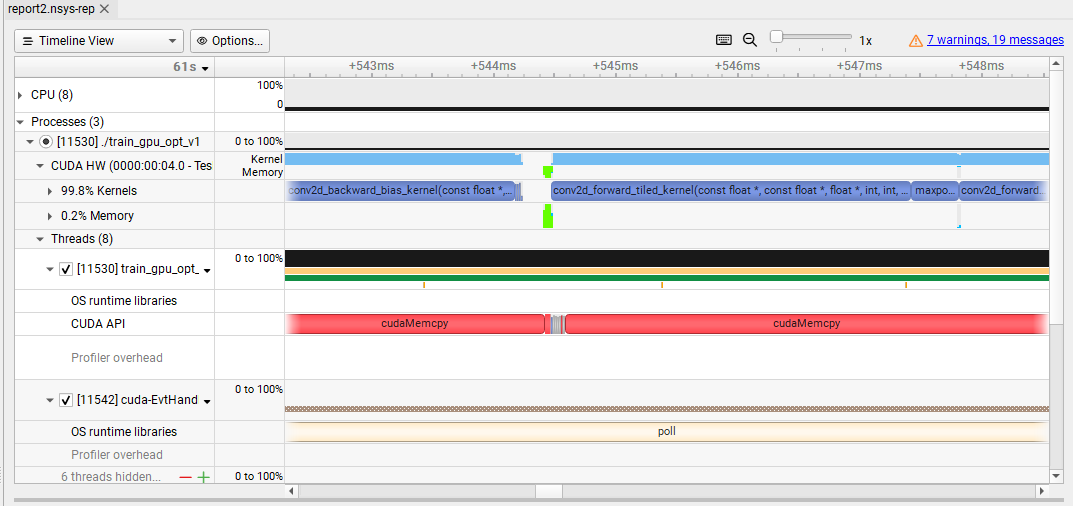


Dựa vào kết quả profiling xuất ra `opt_v1.txt`, ta có


**CUDA API Summary (cuda_api_sum):**

| Time (%) | Total Time (ns) | Name                             |
|----------|-----------------|----------------------------------|
|   99.6   | 182593865678    | cudaMemcpy                       |
|    0.1   |   192558838     | cudaMemGetInfo                   |
|    0.1   |   183710553     | cudaLaunchKernel                 |
|    0.1   |   168304130     | cudaEventSynchronize             |
|    0.0   |    61944018     | cudaMemcpyToSymbol               |
|    0.0   |    26313531     | cudaFree                         |
|    0.0   |    20685226     | cudaMemset                       |
|    0.0   |    18749914     | cudaMalloc                       |
|    0.0   |       91546     | cudaGetDeviceProperties_v2_v12000|
|    0.0   |       19846     | cudaEventRecord                  |
|    0.0   |       18041     | cudaEventCreate                  |
|    0.0   |        6277     | cudaEventDestroy                 |
|    0.0   |        2093     | cuModuleGetLoadingMode           |


 **CUDA GPU Kernel Summary (cuda_gpu_kern_sum):**

| Time (%) | Total Time (ns) | Name                                                                                                   |
|----------|-----------------|--------------------------------------------------------------------------------------------------------|
|   49.6   |  90605998983    | conv2d_backward_weights_kernel(const float *, const float *, float *, int, int, int, int, int, int,…)  |
|   26.9   |  49223107871    | conv2d_forward_tiled_kernel(const float *, const float *, float *, int, int, int, int, int, int, in…)  |
|   13.2   |  24150343062    | conv2d_backward_input_kernel(const float *, const float *, float *, int, int, int, int, int, int, i…)  |
|    9.0   |  16357352406    | conv2d_backward_bias_kernel(const float *, float *, int, int, int, int)                                |
|    0.4   |    787280827    | relu_backward_kernel(const float *, const float *, float *, int)                                       |
|    0.3   |    494254833    | maxpool2d_backward_kernel(const float *, const int *, float *, int)                                   |
|    0.2   |    398089045    | upsample2d_forward_kernel(const float *, float *, int, int, int, int, int, int)                       |
|    0.2   |    341722984    | maxpool2d_forward_kernel(const float *, float *, int *, int, int, int, int, int, int)                 |
|    0.1   |    271662593    | upsample2d_backward_kernel(const float *, float *, int, int, int, int, int, int)                      |
|    0.0   |     32524399    | sgd_update_kernel(float *, const float *, float, int)                                                  |
|    0.0   |      9734258    | mse_loss_forward_kernel(const float *, const float *, float *, int)                                    |
|    0.0   |      3451812    | mse_loss_backward_kernel(const float *, const float *, float *, int, float)                            |

- Ta có thể thấy thời gian thực thi cudaMemcpy đã tăng lên nhưng vẫn còn thấp hơn nhiều so với khoảng thời gian đã tốn cho cudaDeviceSynchronize ở bản trước (giảm ~54.80%), và ở phiên bản này hầu như không có cudaDeviceSynchronize - giảm đáng kể so với con số 404017436921ns ở phiên bản trước

- Mặc dù chiếm tỷ trọng phần trăm nhiều nhất ở phiên bản này, conv2d_backward_weights_kernel vẫn nhỏ hơn rất nhiều so với kernel tốn nhiều thời gian nhất ở phiên bản trước là conv2d_backward_input_kernel_naive (nhỏ hơn ~ 44.4%) và cũng đã được tối ưu đáng kể so với bản trước (giảm ~50.37% so với bản trước)

- Dựa vào các thông số trên, có thể thấy phiên bản này hai hàm kernel chiếm phần lớn thời gian nhất lần lượt là conv2d_backward_weights_kernel (49.6%) và conv2d_forward_tiled_kernel (26.9%). Với câu lệnh `ncu --set basic ./build/train_gpu_opt_v1`, ta có được báo cáo chi tiết cho các hàm kernel, nhưng ta sẽ tập trung vào thông số hai hàm trên (chiếm hơn 76% thời gian).

- Ta có thông số của hàm conv2d_backward_weights_kernel (với các kích cỡ layer khác nhau)

| Chỉ số                       | (1152, 1, 1)x(256, 1, 1) | (27, 1, 1)x(256, 1, 1) | (27, 1, 1)x(256, 1, 1) (2) | (1152, 1, 1)x(256, 1, 1) (2) | (576, 1, 1)x(256, 1, 1) | (1152, 1, 1)x(256, 1, 1) (3) | (27, 1, 1)x(256, 1, 1) (3) | Trung bình |
| :--------------------------- | :----------------------- | :--------------------- | :------------------------- | :--------------------------- | :---------------------- | :--------------------------- | :------------------------- | :------ |
| Memory Throughput            | 49.59 %                  | 33.42 %                | 33.60 %                    | 49.60 %                      | 47.92 %                 | 49.57 %                      | 33.44 %                    | 42.45 % |
| DRAM Throughput              | 2.93 %                   | 2.20 %                 | 3.77 %                     | 1.51 %                       | 0.31 %                  | 2.96 %                       | 2.20 %                     | 2.27 %  |
| Compute (SM) Throughput      | 24.26 %                  | 12.19 %                | 11.11 %                    | 24.28 %                      | 33.82 %                 | 24.25 %                      | 12.20 %                    | 20.30 % |
| Achieved Occupancy           | 95.16 %                  | 25.00 %                | 24.99 %                    | 95.21 %                      | 90.93 %                 | 95.16 %                      | 25.00 %                    | 64.49 % |
| Achieved Active Warps Per SM | 30.45                    | 8.00                   | 8.00                       | 30.47                        | 29.10                   | 30.45                        | 8.00                       | 20.64   |

- Ta có thông số của hàm conv2d_forward_tiled_kernel (với các kích cỡ layer khác nhau)

| Chỉ số | (4, 256, 64) | (1, 128, 64) | (1, 128, 64) | (1, 256, 64) | (4, 3, 64) | Trung bình |
| :--- | :--- | :--- | :--- | :--- | :--- | :--- |
| Memory Throughput % | 67.60 | 66.55 | 56.95 | 67.12 | 65.79 | 64.80 |
| DRAM Throughput % | 5.56 | 0.19 | 0.12 | 0.19 | 4.52 | 2.12 |
| Compute (SM) Throughput % | 67.60 | 66.55 | 56.95 | 67.12 | 65.79 | 64.80 |
| Achieved Occupancy % | 65.61 | 68.61 | 68.50 | 68.71 | 67.32 | 67.75 |
| Achieved Active Warps Per SM | 21.00 | 21.95 | 21.92 | 21.99 | 21.54 | 21.68 |

- **Nhận xét kết quả:**
    - Việc sử dụng Shared Memory và Constant Memory cho `conv2d_forward` đã giảm đáng kể số lần truy cập Global Memory (DRAM), giúp kernel này chạy nhanh hơn rõ rệt.

- **Từ kết quả của profiling:**
    - conv2d_backward_weights_kernel hiện chiếm tỷ trọng thời gian lớn nhất (49.6%)
    - conv2d_forward_tiled_kernel sau khi đã tối ưu chỉ chiếm ~26.9%.
    - Các kernel khác chiếm tỷ trọng rất nhỏ (< 1%).
    - API `cudaMemcpy` chiếm thời gian rất lớn trong tổng thời gian gọi đến các cuda API (99.6%).
    - Việc áp dụng kỹ thuật Tiling (trong forward kernel) và các tối ưu hóa khác đã giảm thiểu đáng kể lưu lượng truy cập DRAM (DRAM Throughput giảm), giảm áp lực lên băng thông bộ nhớ và tăng hiệu suất tổng thể.

- **Performance metrics:**
    - conv2d_backward_weights_kernel và conv2d_forward_tiled_kernel có DRAM Throughput rất thấp (2.27% và 2.12%) chứng tỏ hiệu quả của việc sử dụng shared memory.
    - Occupancy của conv2d_backward_weights_kernel đã được cải thiện đáng kể so với phiên bản trước (tăng từ ~31% lên ~64.5%), mặc dù vẫn còn sự chênh lệch lớn giữa các lần chạy (từ 25% đến 95%).

- **Vấn đề cần giải quyết tiếp theo:**
    - Việc phải gọi nhiều cudaMemcpy đang đồng nghĩa chương trình còn chưa tận dụng được sự song sóng trên nhiều luồng, chưa song song được giữa các kênh truyền dữ liệu

### **2.3.6 Key takeaways**



- **Bài học rút ra:**
    - Kỹ thuật Tiling chứng minh hiệu quả rõ rệt trong việc giảm memory traffic, nhưng đòi hỏi xử lý biên cẩn thận và code phức tạp hơn.
    - Áp dụng thêm Constant Memory vừa dễ cài đặt vừa hiệu quả cho các tham số nhỏ như bias.

- **Cơ hội tối ưu hóa tiếp theo:**
    - Áp dụng hàm truyền dữ liệu không synchronous như cudaMemcpyAsync để khắc phục điểm nghẽn trong pipeline
    - Áp dụng thêm logic phân luồng để song song thao tác xử lí trên các kênh truyền dữ liệu

## **2.4 GPU Optimized Implementation - Version 2**

### **2.4.1 Optimization Focus**


- Việc cải thiện tốc độ thực thi của các kernel bằng cách lưu dữ liệu ở vùng nhớ có tốc độ truy cập nhanh hơn đã giảm thời gian thực thi nhiều lần so với phương pháp ban đầu. Vào bước tối ưu tiếp theo ta sẽ tiến hành song song giữa các luồng làm việc và kết hợp các kernel để giảm thiểu thời gian đọc, ghi dữ liệu giữa các quá trình (tính toán giữa các batch).

- Ở phiên bản trước, ta sử dụng constant memory để lưu trữ bias. Nhưng việc sử dụng `cudaMemcpySymbol` (vốn dĩ là một thao tác synchronous) để sao chép bias từ global sang constant memory khiến ta không thể sử dụng stream để song song giữa các quá trình với nhau được. Đồng thời việc sao chép dữ liệu từ 2 vùng nhớ liên tục cho bias (dữ liệu nhỏ) cũng không tỏ ra tối ưu nhiều so với việc truy cập trực tiếp global memory cho bias.

- Vì bản chất của bài toán, các bước trong forward không thể dùng các stream khác nhau vì các layers sau dùng dữ liệu truyền từ các layers trước và đồng thời bước forward ở batch tiếp theo lại cần việc cập nhật trong số diễn ra ở bước backward của batch trước. Nên ta chỉ có thể tiến hành sử dụng stream ở quá trình load dữ liệu từ host sang device và quá trình tính toán trên kernel.

### **2.4.2 Targets**


Song song hóa quá trình đọc dữ liệu từ host sang device và quá trình tính toán trên device, đồng thời giảm được thời gian truyền dữ liệu giữa các kernels. Mục tiêu giảm từ 2-5% thời gian thực thi chương trình.

### **2.4.3 Implementation Details**

- Thực hiện song song quá trình chuyển đổi dữ liệu và tính toán GPU:

    - Ở phiên bản này, quá trình sao chép dữ liệu từ host sang device được thực hiện cùng thời điểm với quá trình thực thi kernel bằng CUDA stream. Khi dữ liệu đang được xử lý ở batch này thì dữ liệu được dùng cho batch tiếp theo đã được nạp từ host sang device.

```cpp
    cudaStream_t stream1, stream2;
    cudaStreamCreate(&stream1);
    cudaStreamCreate(&stream2);

    for (int batch = 0; batch < num_batches; ++batch) {
        // Async copy next batch to device while previous batch is computing
        cudaMemcpyAsync(d_input[batch % 2], h_input[batch], batch_size * sizeof(float),
                        cudaMemcpyHostToDevice, (batch % 2 == 0) ? stream1 : stream2);

        // Launch kernel on the stream for this batch
        my_kernel<<<grid, block, 0, (batch % 2 == 0) ? stream1 : stream2>>>(d_input[batch % 2], ...);

        // Optionally, async copy output back
        cudaMemcpyAsync(h_output[batch], d_output[batch % 2], batch_size * sizeof(float),
                        cudaMemcpyDeviceToHost, (batch % 2 == 0) ? stream1 : stream2);
    }
    cudaStreamSynchronize(stream1);
    cudaStreamSynchronize(stream2);
```


- Hợp nhất các kernel:

    - Phiên bản này tiến hành hợp nhất các kernel làm việc liền kề nhau (convolution, activation và pooling).

    - kỹ thuật này loại bỏ việc ghi kết quả trung gian ra global mem rồi đọc lại, giữ dữ liệu trên các thanh ghi, giảm 2/3 lượng tủy cập bộ nhớ cho các lớp kích hoạt và diamgr độ trễ đáng kể.

```cpp
    __global__ void conv2d_relu_fused(const float* input, const float* weights, const float* bias, float* output, ...) {
    // ... index calculation ...
    float sum = 0.0f;
    // Convolution
    for (int c = 0; c < C_in; ++c)
        for (int kh = 0; kh < K; ++kh)
            for (int kw = 0; kw < K; ++kw)
                sum += input[...] * weights[...];
    sum += bias[out_c];
    // Fused ReLU activation
    output[...] = max(0.0f, sum);
    }   
```
- Ngoài ra ở phiên bản này, ta còn thực hiện tiling tối ưu hơn và unroll.


### **2.4.4 Results**


Thông số tổng quát
| Metric                    | Value      |
|---------------------------|------------|
| Total training time       | 3589.32 s |
| Average time per epoch    | 179.47 s  |
| GPU memory usage          | 490 MB     |


Bảng so sánh với CPU và phiên bản trước
| Phase | Training Time (s) | Speedup (vs CPU) | Incremental Speedup | Memory Usage (MB) | Key Optimization |
|-------|---------------|------------------|---------------------|-------------------|------------------|
| CPU Baseline | 3,927,270 | 1.00× | – | 1.0 | – |
| GPU Opt v1 | 3,706.07 | 1,059.80× | 2.49× | 490 | Shared memory |
| GPU Opt v2 | 3,589.32 | 1,094.60× | 1.03× | 490 | Kernel Fusion + Streams |

Bảng so sánh thời gian chạy

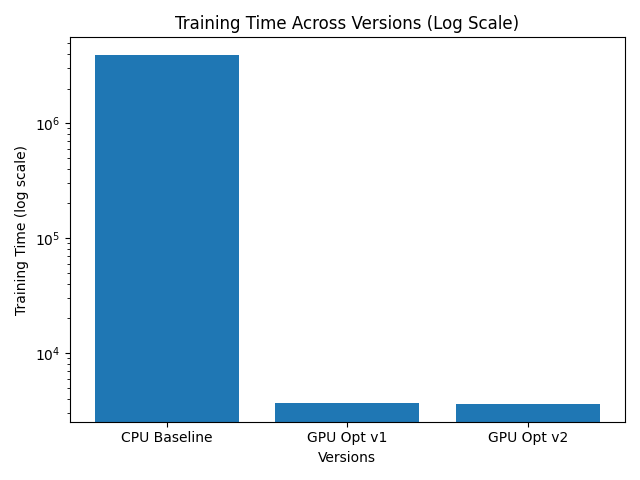



Line chart so sánh thời gian chạy tích lũy so với CPU


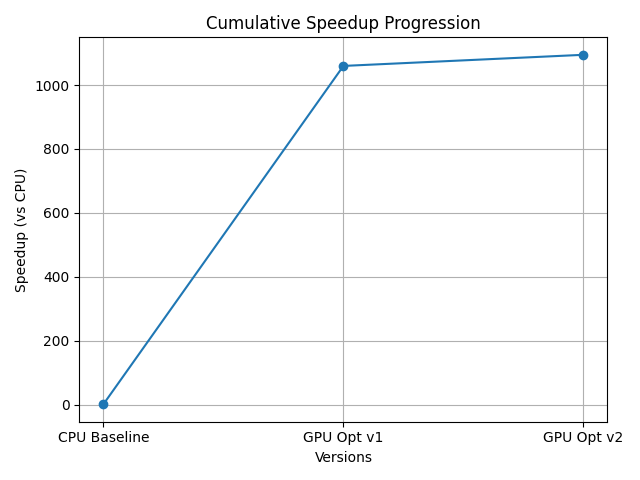

### Nhận xét

#### Tổng quan kết quả
Phiên bản GPU Opt v2 (áp dụng Kernel Fusion + Streams) đã xác lập kỷ lục mới về hiệu năng:
- Tổng thời gian huấn luyện: 3,589.32 giây (chưa đầy 1 giờ).
- Thời gian trung bình mỗi epoch: 179.47 giây.
- Tăng tốc đạt mức cao nhất là 1,094.60 lần so với CPU Baseline.

#### So sánh chi tiết từ GPU Opt v1 sang GPU Opt v2
- Kết quả: Thời gian tiếp tục giảm từ 3,706.07 giây xuống 3,589.32 giây.
- Incremental Speedup: Tăng tốc thêm 1.03 lần (tương đương cải thiện khoảng 3%).
- Kỹ thuật: Kernel Fusion và CUDA Streams.
- Nhận xét: Sau khi đã tối ưu rất tốt ở v1, việc cải thiện thêm hiệu năng trở nên khó khăn hơn. Tuy nhiên, mức tăng 3% vẫn rất đáng giá trong các hệ thống quy mô lớn khi scale bài toán lên nữa. Kỹ thuật Kernel Fusion giúp giảm overhead khi gọi kernel trong khi Streams giúp che giấu độ trễ (latency hiding) làm cho luồng xử lý mượt mà hơn.

#### Phân tích biểu đồ

- Biểu đồ bar chart training time:
  - Cột CPU Baseline vẫn chiếm ưu thế tuyệt đối về độ cao do thời gian chạy quá lớn.
  - Sự khác biệt giữa cột `GPU Opt v1` và `GPU Opt v2` là không đáng kể trên thang đo logarit nhưng số liệu thực tế cho thấy v2 thấp hơn.

- Biểu đồ line chart cumulative speedup progression:
  - Đường biểu diễn tiếp tục đi lên tại điểm cuối cùng.
  - Từ mốc ~1060x ở v1, đường đồ thị nhích nhẹ lên tiệm cận mốc 1100x ở v2. Điều này cho thấy trần hiệu suất đang dần được chạm tới.

#### Đánh giá về GPU usage
- Bộ nhớ GPU giữ nguyên ở mức 490MB.
- Nhận xét: Điểm sáng của phiên bản v2 là **tăng tốc độ mà không tốn thêm tài nguyên**. Mức tiêu thụ bộ nhớ giữ nguyên ở 490 MB chứng tỏ kỹ thuật Kernel Fusion và Streams chủ yếu tối ưu về mặt lập lịch (scheduling) và giảm overhead tính toán chứ không yêu cầu thêm không gian lưu trữ đệm. Đây là một sự tối ưu "miễn phí" về mặt không gian.

### **2.4.5 Profiling analysis**


Profiling GPU OPT V2


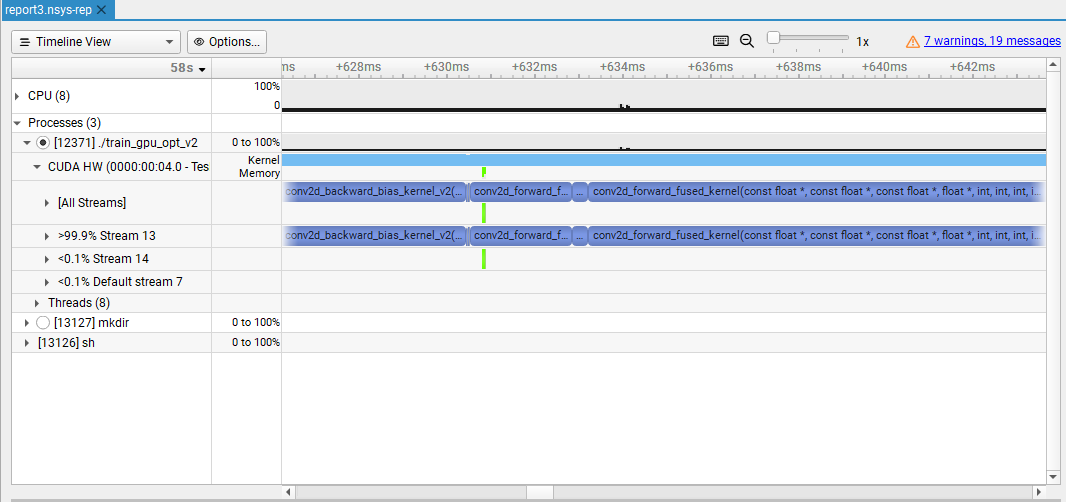

Dựa trên kết quả profiling xuất ra `opt_v2.txt`, ta có:


 **CUDA API Summary (cuda_api_sum):**

| Time (%) | Total Time (ns) | Name                             |
|----------|-----------------|-----------------------------------|
| 96.6     | 172641371751    | cudaLaunchKernel                  |
| 2.8      | 5028316343      | cudaStreamSynchronize             |
| 0.3      | 520209138       | cudaMemcpyAsync                   |
| 0.1      | 249758939       | cudaMemsetAsync                   |
| 0.1      | 190259659       | cudaMemGetInfo                    |
| 0.0      | 10835017        | cudaFree                          |
| 0.0      | 4403256         | cudaEventRecord                   |
| 0.0      | 2526783         | cudaStreamWaitEvent               |
| 0.0      | 2177550         | cudaMemcpy                        |
| 0.0      | 2037392         | cudaMalloc                        |
| 0.0      | 91894           | cudaGetDeviceProperties_v2_v12000 |
| 0.0      | 31115           | cudaStreamCreate                  |
| 0.0      | 22031           | cudaStreamDestroy                 |
| 0.0      | 7834            | cudaEventDestroy                  |
| 0.0      | 5282            | cudaEventCreateWithFlags          |
| 0.0      | 4292            | cudaEventSynchronize              |
| 0.0      | 2558            | cudaEventCreate                   |
| 0.0      | 1944            | cuModuleGetLoadingMode            |

 **CUDA GPU Kernel Summary (cuda_gpu_kern_sum):**

| Time (%) | Total Time (ns) | Name                                                                                                   |
|----------|-----------------|----------------------------------------------------------------------------------------------------------|
| 51.1     | 91180446819     | conv2d_backward_weights_kernel_v2(const float *, const float *, float *, int, int, int, int, int, ...)   |
| 24.5     | 43774711130     | conv2d_forward_fused_kernel(const float *, const float *, const float *, float *, int, int, int, ...)    |
| 13.8     | 24554640619     | conv2d_backward_input_kernel_v2(const float *, const float *, float *, int, int, int, int, int, int ...) |
| 9.3      | 16501649359     | conv2d_backward_bias_kernel_v2(const float *, float *, int, int, int, int)                               |
| 0.4      | 785607692       | relu_backward_kernel_v2(const float *, const float *, float *, int)                                      |
| 0.3      | 492842080       | maxpool2d_backward_kernel_v2(const float *, const int *, float *, int)                                   |
| 0.2      | 408588345       | upsample2d_forward_kernel_v2(const float *, float *, int, int, int, int, int, int)                      |
| 0.2      | 341585076       | maxpool2d_forward_kernel_v2(const float *, float *, int *, int, int, int, int, int, int)                |
| 0.2      | 271354044       | upsample2d_backward_kernel_v2(const float *, float *, int, int, int, int, int, int)                     |
| 0.0      | 32513938        | sgd_update_kernel_v2(float *, const float *, float, int)                                                 |
| 0.0      | 10285786        | mse_loss_forward_kernel_v2(const float *, const float *, float *, int)                                   |
| 0.0      | 3548073         | mse_loss_backward_kernel_v2(const float *, const float *, float *, int, float)                           |

- So với bản cải tiến lần 1, cudaMemcpyAsync đã được khai thác nhiều hơn cho việc song song hóa việc xử lí với việc truyền dữ liệu. Phần lớn thời gian của việc gọi cuda API đến từ cudaLaunchKernel, tăng lên rất nhiều so với ở bản 1, song vẫn nhanh hơn cuda API tốn nhiều thời gian nhất bản 1 là cudaMemcpy (172641371751 < 182593865678)

- Ở phiên bản cải tiến này, kernel liên quan đến thực hiện backward của convolution vẫn chiếm tỉ trọng lớn nhất về mặt thời gian (hơn 50% tổng thời gian của kernel) nhưng đã được tối ưu hóa đáng kể khi chỉ tốn xấp xỉ một nửa thời gian của phiên bản trước. Nói cách khác, sự cải tiến đã giúp rút ngắn gần như gấp đôi thời gian chạy của kernel lâu nhất của phiên bản 1

- Dễ thấy các cải tiến đều nhắm đúng vào các điểm nghẽn, khai thác các tiềm năng xác định ở phiên bản trước, giúp nâng hiệu suất toàn bộ pipeline một cách rõ rệt

### **2.4.6 Key takeaways**


- **Những cách đã tối ưu:**
    
    - Việc gộp các thao tác Convolution, Bias addition và ReLU vào một kernel duy nhất (`conv2d_forward_fused_kernel`) đã chứng minh hiệu quả rõ rệt, giảm thiểu truy cập bộ nhớ dư thừa và overhead khi launch kernel.

    - Việc hiện thực pipeline đa luồng cho phép chồng lấp (overlap) giữa tính toán và truyền dữ liệu, tận dụng tối đa tài nguyên của GPU về tính toán và kênh truyền dữ liệu mặc dù thời gian cải thiện không được cao do bản chất quá trình load dữ liệu từ host sang device của bài toán này (batch size 64) tốn không nhiều thời gian.

- **Những cách tiếp theo có thể tối ưu:**
    
    - Áp dụng các thuật toán tích chập nhanh như Winograd, Im2Col (cuBlas trong CUDA kit) hoặc FFT để cải thiện tốc độ tính toán.
    
    - Kết quả profiling (`opt_v2.txt`) cho thấy `conv2d_backward_weights_kernel_v2` chiếm 51.1% tổng thời gian, đồng nghĩa với một điểm nghẽn có thể được tối ưu thêm.


## **2.5 SVM Integration**


### **2.5.1 Objectives**


- Huấn luyện bộ phân loại SVM trên các đặc trưng đã trích xuất
- Ghi nhận và đánh giá hiệu quả phân loại của pipeline
- Kiểm định chất lượng đặc trưng học được thông qua độ chính xác phân loại


### **2.5.2 Implementation details**


**Trích xuất đặc trưng:**
- Tải trọng số encoder đã huấn luyện từ quá trình training autoencoder
- Thực hiện forward pass qua encoder (không qua decoder) cho toàn bộ tập ảnh huấn luyện (50.000) và tập ảnh kiểm thử (10.000)
- Trích xuất latent space và chuyển đổi từ dạng (N, 8, 8, 128) sang dạng 1 chiều, lưu thành tập tin nhị phân

**Tích hợp LIBSVM:**
- Sử dụng thư viện LIBSVM để huấn luyện và dự đoán SVM
- Tạo ra các hàm khởi tạo svm_nodes, svm_problem, hàm giải phóng vùng nhớ svm_problem, hàm tính gamma
- Dùng các hàm trên để chuyển đổi vector đặc trưng sang định dạng svm_problem với các svm_node cho phù hợp LIBSVM API

**Hyperparameters:**
- Kernel: RBF (Radial Basis Function)
- C: 10.0 (như yêu cầu)
- Gamma: auto (1/N)
- eps: 0.001
- Cache size: 100


Tham số được thiết lập rồi kiểm tra hợp lệ qua `svm_check_parameter` trước khi train.

**Key Code Snippets:**

_Bản CPU và GPU tương tự nhau, nên chúng em để đại diện CPU (phiên bản cơ sở)_

- Feature extraction code
    ```cpp
    Tensor AutoencoderCPU::extract_features(const Tensor &input)
    {
        // Run only the encoder path
        auto x = conv1_->forward(input);
        x = relu1_->forward(x);
        x = pool1_->forward(x);

        x = conv2_->forward(x);
        x = relu2_->forward(x);
        x = pool2_->forward(x); // Returns (8,8,128) = 8192 features

        return x;
    }
    ```
    ```cpp
    Tensor latent = model.extract_features(batch_tensor);
            const float *latent_data = latent.raw_data();

            for (int i = 0; i < current_batch_size; ++i)
            {
                std::vector<float> feature_vec(FEATURE_DIM);
                std::copy(latent_data + i * FEATURE_DIM,
                          latent_data + (i + 1) * FEATURE_DIM,
                          feature_vec.begin());
                train_features.push_back(std::move(feature_vec));
            }
    ```

- SVM training interface
    ```cpp
    //Forward declaration (function signatures)
    svm_node *create_svm_nodes(const std::vector<float> &features);
    svm_problem *create_svm_problem(const std::vector<std::vector<float>> &features, const std::vector<int> &labels);
    void free_svm_problem(svm_problem *prob);
    double calculate_gamma_auto(int num_features);

    // Setup SVM parameters
        svm_parameter param;
        param.svm_type = C_SVC;
        param.kernel_type = RBF;
        param.gamma = calculate_gamma_auto(feature_dim); // gamma = 1 / num_features
        param.cache_size = 100;
        param.C = 10.0;
        param.eps = 1e-3;

        // Create training problem
        cout << "Preparing training data...\n";
        svm_problem *prob = create_svm_problem(train_features, train_labels);

        // Check parameters
        const char *error_msg = svm_check_parameter(prob, &param);

        // Train SVM
        auto start = std::chrono::high_resolution_clock::now();

        svm_model *model = svm_train(prob, &param);

        // Predict on training set
        int train_correct = 0;
        for (int i = 0; i < num_train; ++i)
        {
            svm_node *x = prob->x[i];
            double pred = svm_predict(model, x);
            if ((int)pred == train_labels[i])
            {
                train_correct++;
            }
        }
        double train_accuracy = 100.0 * train_correct / num_train;
    ```

- Prediction and evaluation code
    ```cpp
    // Predict on test set
        int test_correct = 0;
        std::vector<int> predictions(num_test);

        // Confusion matrix
        int confusion[CIFAR_CLASSES][CIFAR_CLASSES] = {0};

        for (int i = 0; i < num_test; ++i)
        {
            svm_node *x = create_svm_nodes(test_features[i]);

            double pred = svm_predict(model, x);
            int pred_label = (int)pred;
            int true_label = test_labels[i];

            predictions[i] = pred_label;

            if (pred_label == true_label)
            {
                test_correct++;
            }

            confusion[true_label][pred_label]++;

            delete[] x;
        }

        double test_accuracy = 100.0 * test_correct / num_test;
    ```


### **2.5.3 Results**


#### Bản CPU
- Thời gian trích xuất đặc trưng (500 mẫu huấn luyện + 500 mẫu kiểm thử): 756.79s
- Thời gian huấn luyện SVM: 8.31494s
- Độ chính xác phân loại trên tập kiểm thử tổng thể: 32%

- Bảng phân tích độ chính xác theo từng lớp (per-class accuracy)

| Class | Accuracy |
|-------|----------|
| airplane | 38.5965% |
| automobile | 39.0244% |
| bird | 15.6863% |
| cat | 8.16327% |
| deer | 50.0000% |
| dog | 8.33333% |
| frog | 42.5926% |
| horse | 21.2766% |
| ship | 42.1053% |
| truck | 51.7857% |

- Confusion matrix


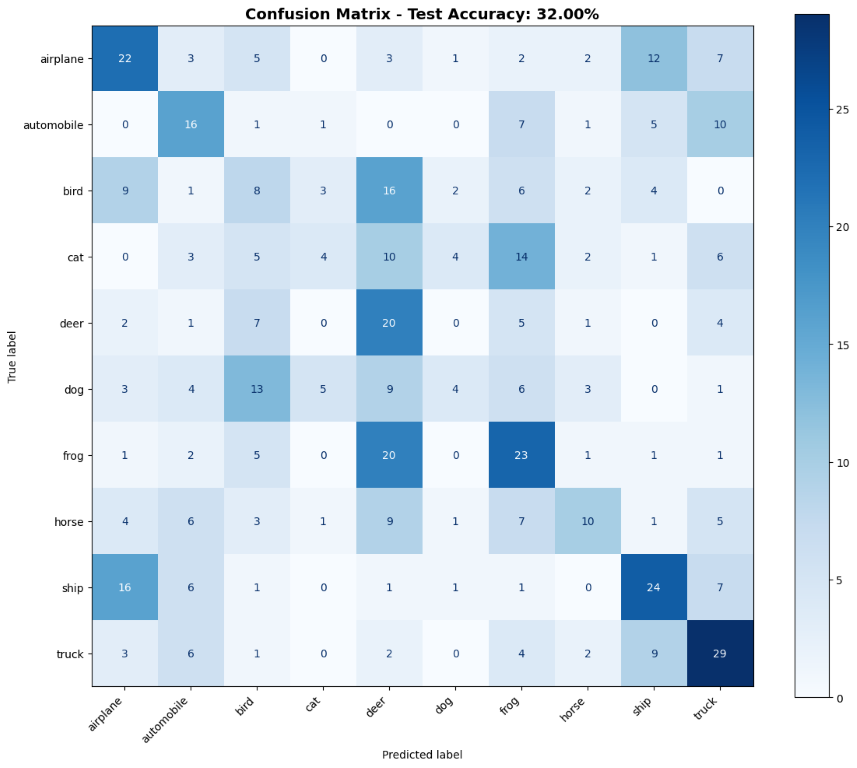

- Độ chính xác trên tập huấn luyện: 59.8%


#### Bản GPU

Thông tin tổng quan

| Metric | Value |
|--------|-------|
| Training samples | 50,000 |
| Test samples | 10,000 |
| Feature dimension | 8,192 |

Thời gian chạy và độ chính xác giữa các phiên bản

| Implementation | Feature extraction time (s) | SVM training time (s) | Train accuracy (%) | Test accuracy (%) |
|---------------|----------------------------:|------------------:|-------------------:|------------------:|
| Naive         | 36.50                       | 62.27             | 95.98              | 63.03             |
| Opt_v1        | 29.29                       | 63.47             | 99.37              | 63.97             |
| Opt_v2        | 26.39                       | 62.82             | 98.66              | 66.70             |

Độ chính xác từng class

| Class       | Naive (%) | Opt_v1 (%) | Opt_v2 (%) |
|-------------|-----------:|-----------:|-----------:|
| airplane    | 70.40      | 69.00      | 71.90      |
| automobile  | 71.60      | 73.60      | 76.30      |
| bird        | 49.00      | 49.20      | 52.60      |
| cat         | 48.20      | 51.70      | 52.80      |
| deer        | 55.80      | 57.80      | 62.90      |
| dog         | 55.30      | 53.90      | 57.60      |
| frog        | 71.70      | 71.30      | 73.60      |
| horse       | 65.70      | 67.60      | 70.30      |
| ship        | 75.20      | 75.20      | 77.00      |
| truck       | 67.40      | 70.40      | 72.00      |


##### Confusion matrix Naive



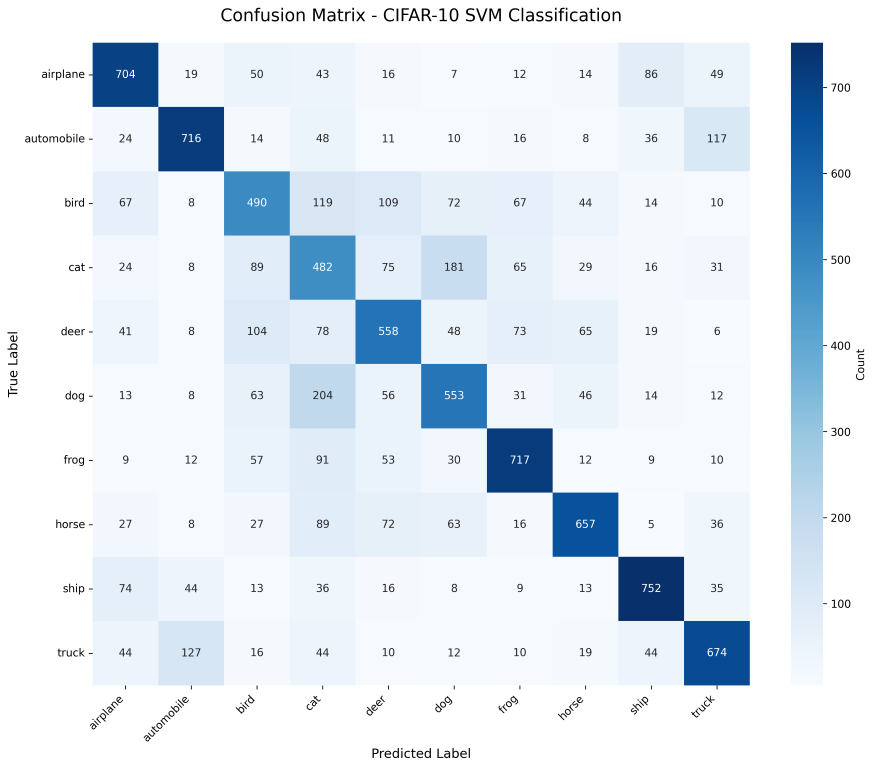

##### Confusion matrix Opt_V1


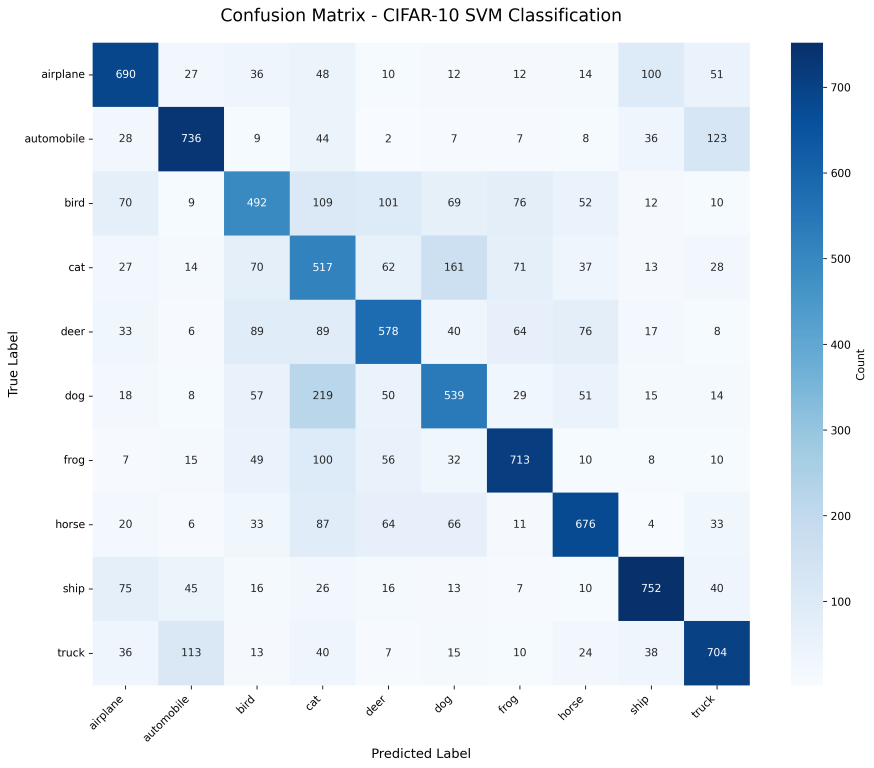

##### Confusion matrix Opt_V2

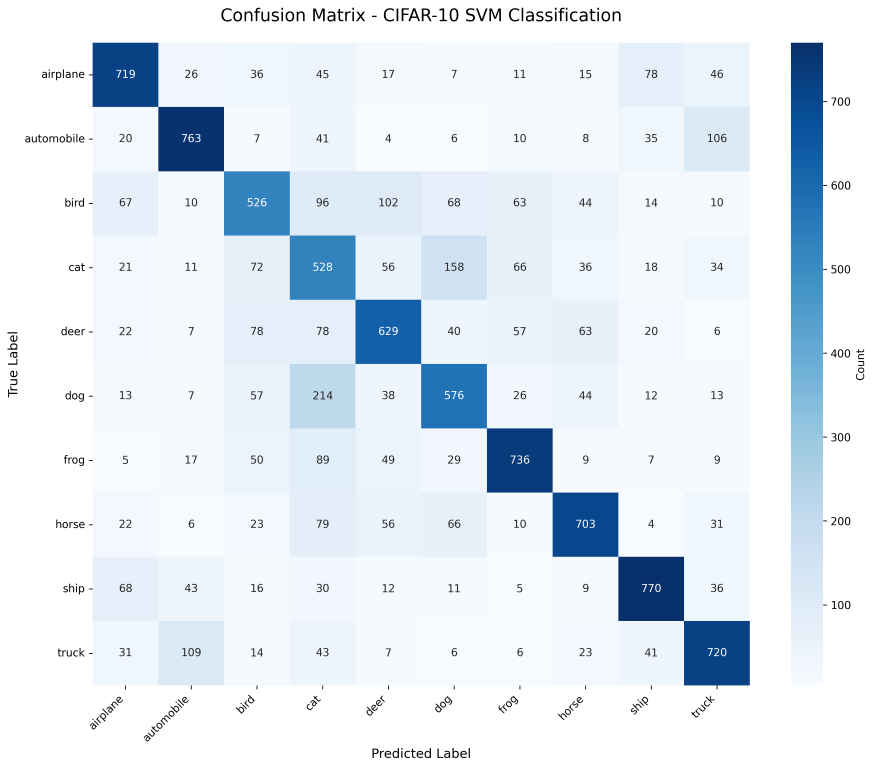

### **2.5.4 Analysis**

#### Bản CPU
- **Những lớp dễ phân loại nhất:** truck (51.79%), deer (50%), frog (42.59%), ship (42.11%), automobile (39.02%), airplane (38.60%).

- **Những lớp khó phân loại nhất:** cat (8.16%), dog (8.33%), horse (21.28%), bird (15.69%).

- **Confusion matrix:** Cho thấy các lớp như cat, dog, horse, bird thường bị nhầm lẫn lẫn nhau và với các lớp khác, đặc biệt là cat và dog. Trong khi các lớp phương tiện (airplane, ship, truck, automobile) phân biệt tốt hơn.

- **Độ chính xác đạt được (32%) thấp hơn kỳ vọng (60-65%)**

- **Nhận xét**: Do chỉ lấy 500 ảnh để train và 500 ảnh để test có thể chưa phản ánh toàn bộ hiệu năng của pipeline, bản GPU sẽ phản ánh tốt hơn.

#### Bản GPU


### Nhận xét

#### Thời gian chạy
- **Feature Extraction:** Có sự cải thiện rõ rệt qua từng phiên bản. Thời gian giảm từ 36.50s (Naive) xuống 29.29s (Opt_v1) và đạt mức thấp nhất 26.39s (Opt_v2). Cho thấy các kỹ thuật tối ưu hóa (như tối ưu bộ nhớ hoặc luồng) đã tác động hiệu quả vào giai đoạn trích xuất đặc trưng giúp giảm khoảng **27.7%** thời gian so với bản Naive.

- **SVM Training:** Thời gian huấn luyện SVM khá ổn định (dao động quanh mức 62-63s).

- **Train Accuracy & Overfitting:**
  - Cả 3 phiên bản đều có độ chính xác huấn luyện rất cao (96% - 99%), trong khi tập test chỉ đạt khoảng 63% - 66%.
  - Sự chênh lệch lớn (>30%) chứng tỏ mô hình đang gặp hiện tượng **Overfitting** nặng.
  
- **Test Accuracy (Khả năng tổng quát hóa):** Phiên bản **Opt_v2** là phiên bản tốt nhất. Độ chính xác trên tập kiểm thử tăng dần: 63.03% (Naive) -> 63.97% (Opt_v1) -> **66.70% (Opt_v2)**.



- **Class-wise accuracy**: Lớp Deer có sự cải thiện ấn tượng nhất ở phiên bản Opt_v2 (tăng từ 55.8% lên 62.9%) cùng với Dog và Frog.
- **Những lớp dễ phân loại nhất:** Ship (~75-77%) , Automobile (~72-76%), Frog (71-74%)

- **Những lớp khó phân loại nhất:** Bird (~49-53%), Cat (~48-53%), Dog (~54-58%)

- **Confusion matrix** tương tự như với bản CPU cho thấy các lớp như cat, dog, bird thường bị nhầm lẫn lẫn nhau. Cat và Dog là sự nhầm lẫn nhiều nhất trong khi Bird có sự lẫn giữa Cat và Deer.

- **Độ chính xác đạt được kỳ vọng (60-65%) và hơn ở bản Opt_V2 với 66.7%**

- **Nhận xét**: Được train hết dataset so với bản CPU và dùng thư viện cuML đã giúp việc training cực kì nhanh và đạt được độ chính xác cao, và chất lượng classify cũng phản ánh việc chất lượng autoencoder đủ tốt để phân biệt giữa các class.

### **2.5.5 Insights**

#### Chất lượng features
- Phụ thuộc trực tiếp vào chất lượng autoencoder
- Nếu autoencoder được huấn luyện tốt sẽ giúp phát hiện ra các mẫu đặc trưng của các ảnh, giúp tăng độ chính xác đáng kể mà vẫn đảm bảo tính khái quát hóa
- Chất lượng feature là bottleneck chính của toàn bộ pipeline

#### Pipeline hai giai đoạn có ưu và nhược điểm
- **Ưu**
    - Có thể giám sát, thay đổi, tinh chỉnh autoencoder và SVM mà không ảnh hưởng đến nhau
    - Tách biệt huấn luyện autoencoder với việc áp dụng nó để rút trích đặc trưng rồi chạy classifier, giúp tăng tính tái sử dụng và có thể áp dụng với nhiều classifier khác nhau
    - Mỗi giai đoạn có thể optimize độc lập với các phương pháp song song hóa trên GPU

- **Nhược**
    - Phải train 2 models riêng biệt, có thể có nhiều điểm tối ưu hóa và mở rộng nếu làm thành một pipeline xuyên suốt (việc đọc, ghi, xử lí các dữ liệu, trực quan hóa, ...)
    - Vì các đặc trưng rút trích ra có thể dùng cho nhiều classifier, chưa có tính chuyên biệt cụ thể (chưa bảo đảm chuyên biệt, tối ưu nhất cho SVM trong pipeline hiện tại)
    - Phải tốn thêm không gian lưu trung gian các kết quả ở dạng nhị phân để đảm bảo tính xuyên suốt cả pipeline

#### So sánh với end-to-end supervised learning
- Pipeline này phù hợp khi có nhiều unlabeled data, ít labeled data và có tiềm năng tổng quát hóa (ở giai đoạn rút trích đặc trưng) cao hơn, đồng thời cho phép linh hoạt trong việc áp dụng classifier
- End-to-end supervised learning pipeline cho phép optimize trực tiếp cho classification, có thể có độ chính xác cao hơn nhưng cần nhiều labeled data hơn.


# **3. Comprehensive Performance Analysis**


_Vì phiên bản CPU chạy 500 ảnh và 2 epoch và nên chúng em lấy trung bình và nhân lên 100 lần để đủ kích thước dataset và 20 lần đủ đủ số thời gian chạy epochs_

## **3.1 Performance Comparison Table**

| Phase | Training Time (s) | Speedup (vs CPU) | Incremental Speedup | Memory Usage (MB) | Key Optimization |
|-------|---------------|------------------|---------------------|-------------------|------------------|
| CPU Baseline | 3,927,270 | 1.00× | – | 1.0 | – |
| GPU Naive | 9,213.01 | 426.30× | 426.30× | 308 | Basic Parallelization |
| GPU Opt v1 | 3,706.07 | 1,059.80× | 2.49× | 490 | Shared memory |
| GPU Opt v2 | 3,589.32 | 1,094.60× | 1.03× | 490 | Kernel Fusion + Streams |

Dưới đây là hình ảnh thể hiện chi tiết thông tin so sánh độ sai số giữa CPU và các phiên bản GPU khi thực hiện inference trên 1 ảnh đầu vào. Có thể xem kết quả trực tiếp bằng cách chạy câu lệnh `./test_comparison_cpu_gpu` sau khi build.

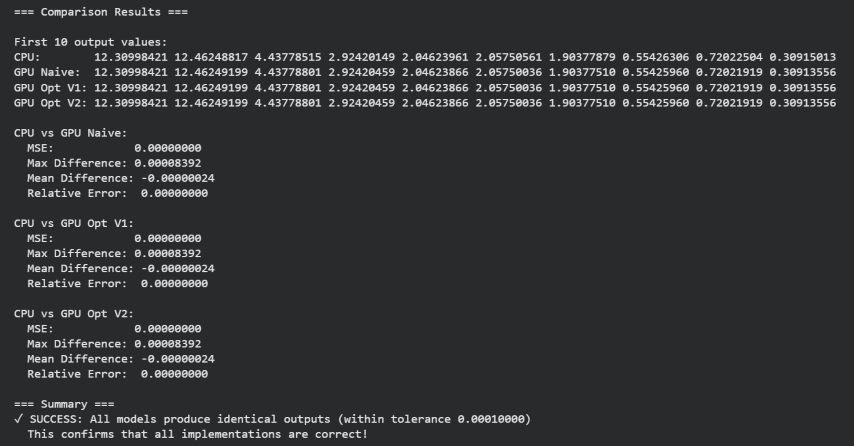

## **3.2 Performance Visualizations**


### Biểu đồ cột so sánh thời gian training của tất cả phiên bản cài đặt


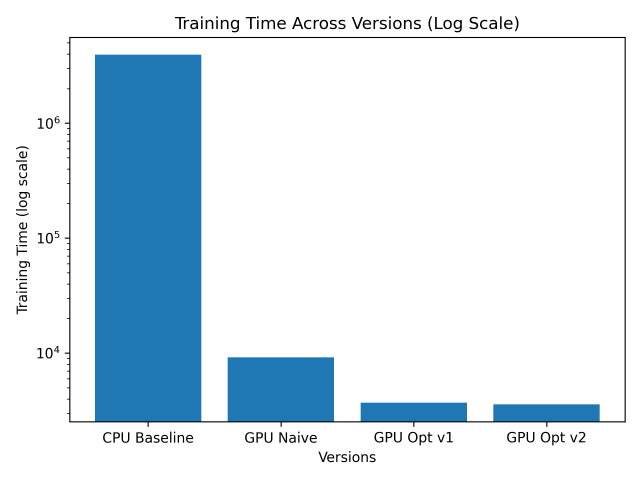

### Biểu đồ đường thể hiện sự tiến triển của mức tăng tốc tích lũy

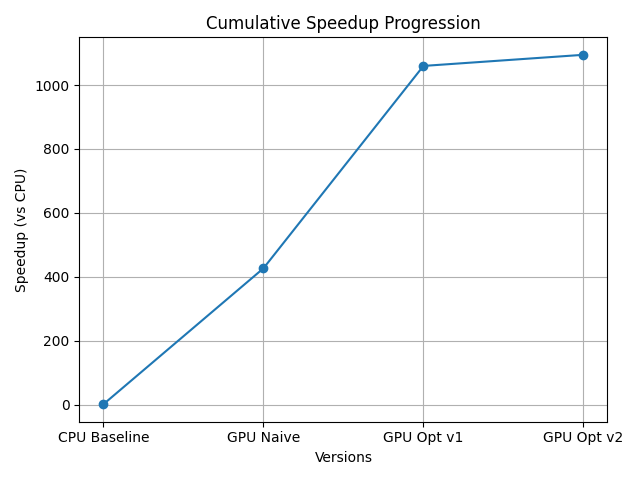

### Nhận xét

#### So sánh chi tiết các giai đoạn phát triển
- **Giai đoạn 1: CPU Baseline → GPU Naive:**
  - Kết quả: Thời gian giảm khổng lồ từ ~3.9 triệu giây xuống 9,213 giây.
  - Speedup: Đạt 426.30 lần.
  - Nhận xét: Đây là bước nhảy vọt lớn nhất. Chỉ cần chuyển đổi sang xử lý song song cơ bản (Basic Parallelization) hiệu năng đã tăng gấp hàng trăm lần giải quyết được bài toán về tính khả thi của thời gian huấn luyện.

- **Giai đoạn 2: GPU Naive → GPU Opt v1:**
  - Kết quả: Thời gian giảm từ 9,213 giây xuống 3,706 giây.
  - Incremental speedup: Tăng tốc thêm 2.49 lần so với bản Naive.
  - Nhận xét: Việc sử dụng Shared Memory giúp giảm độ trễ truy cập bộ nhớ toàn cục và mang lại hiệu quả tăng tốc đáng kể (gấp hơn 2 lần) so với phiên bản GPU cơ bản.

- **Giai đoạn 3: GPU Opt v1 → GPU Opt v2:**
  - Kết quả: Thời gian giảm tiếp từ 3,706 giây xuống 3,589 giây.
  - Incremental speedup: Tăng tốc thêm 1.03 lần.
  - Nhận xét: Khi mã nguồn đã được tối ưu tốt về bộ nhớ, việc áp dụng Kernel Fusion và Streams giúp tối ưu hóa luồng lệnh và che giấu độ trễ (latency hiding) mang lại sự cải thiện nhỏ nhưng quan trọng để đạt đến giới hạn phần cứng.

#### Phân tích biểu đồ
- **Biểu đồ bar chart training time:**
  - Do sự chênh lệch quá lớn giữa CPU (hàng triệu giây) và GPU (hàng nghìn giây) thang đo logarit là bắt buộc để hiển thị dữ liệu.
  - Cột CPU Baseline cao vượt trội trong khi ba cột GPU (Naive, Opt v1, Opt v2) thấp hơn hẳn và giảm dần theo từng phiên bản.

- **Biểu đồ line chart cumulative speedup progression:**
  - Đường biểu diễn đi lên rất dốc ở đoạn đầu (từ CPU lên Naive và từ Naive lên Opt v1).
  - Tại đoạn cuối (v1 sang v2) độ dốc giảm dần và có xu hướng đi ngang cho thấy hiệu suất đang tiệm cận trần giới hạn của phần cứng và các kỹ thuật tối ưu.

#### Đánh giá về GPU usage
- **Bộ nhớ GPU:** Có sự thay đổi rõ rệt giữa các chiến lược tối ưu.
  - GPU Naive: 308 MB.
  - GPU Opt v1 & v2: 490 MB.
- **Nhận xét:**
  - Từ Naive lên Opt v1: Bộ nhớ tăng từ 308 MB lên 490 MB do việc cấp phát Shared Memory. Đây là sự đánh đổi Space-Time tradeoff hoàn toàn xứng đáng.
  - Từ Opt v1 lên Opt v2: Bộ nhớ giữ nguyên ở mức 490 MB. Điều này chứng tỏ kỹ thuật Kernel Fusion và Streams là những tối ưu hóa "miễn phí" về mặt không gian lưu trữ, chỉ tập trung cải thiện hiệu quả lập lịch và thực thi.

### Kết quả ảnh được tái tạo lại từ autoencoder của các version GPU. Ảnh ban đầu và ảnh được tái tạo (từ trái sang phải) các ảnh kết quả tái tạo gần như giống nhau giữa các phiên bản

    - Phiên bản GPU naive

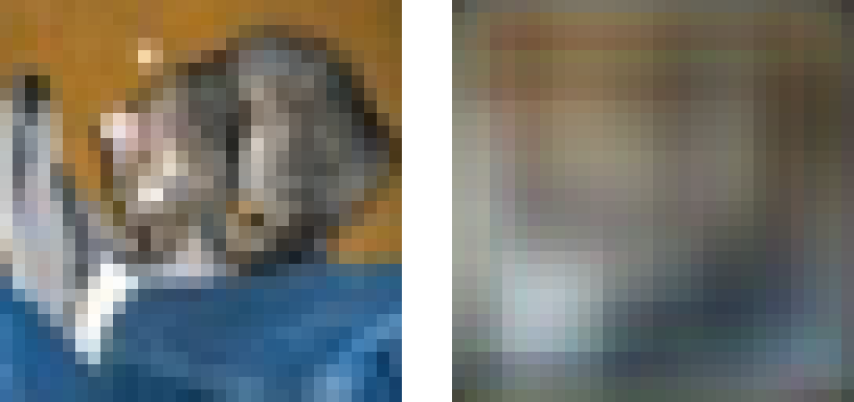

    - Phiên bản GPU optimized V1

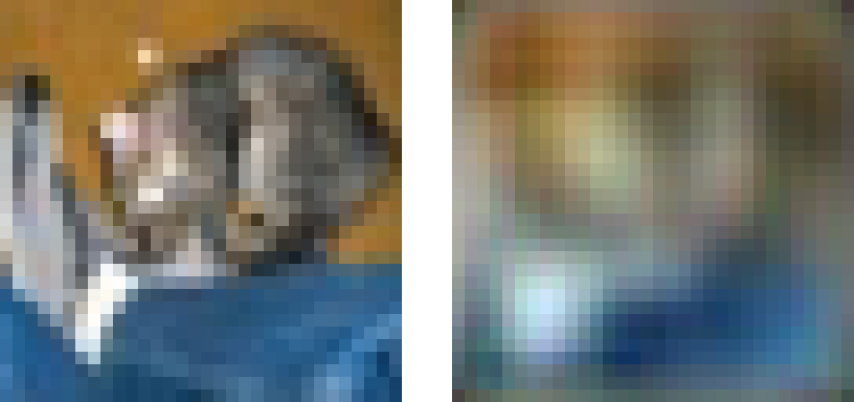

    - Phiên bản GPU optimized V2 

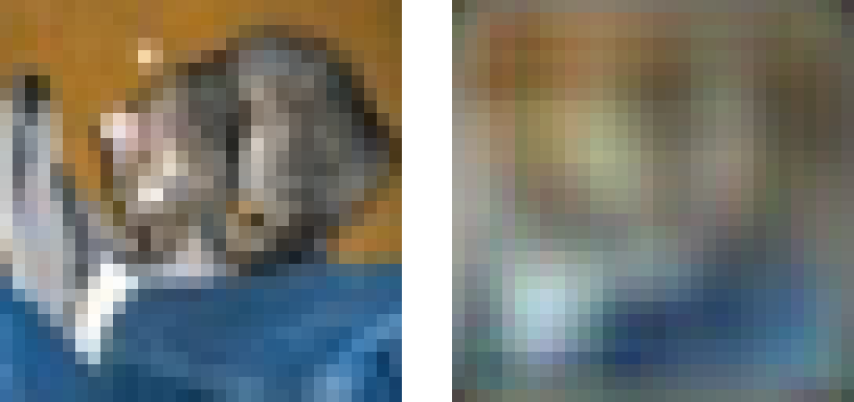

### Thực nghiệm đánh giá trên GPU mạnh hơn (L4 vs T4)

Để đánh giá khả năng mở rộng và phương pháp code có phụ thuộc vào phần cứng hay không, nhóm đã thực hiện so sánh giữa GPU T4 và GPU L4 trên môi trường Colab.

### Kết quả trên T4 GPU
| Implementation | Autoencoder training time (1 epoch) | Feature extraction time | GPU Usage |
| :--- | :--- | :--- | :--- |
| Naive | 460.65s | 36.50s | 308 MB |
| Opt_v1 | 185.30s | 29.29s | 490 MB |
| Opt_v2 | 179.47s | 26.39s | 490 MB |

### Kết quả trên L4 GPU
| Implementation | Autoencoder training time (1 epoch) | Feature extraction time | GPU Usage |
| :--- | :--- | :--- | :--- |
| Naive | 206.14s | 14.04s | 395 MB |
| Opt_v1 | 69.73s | 11.34s | 577 MB |
| Opt_v2 | 68.80s | 11.38s | 577 MB |

#### 1. Hiệu năng phần cứng
Việc nâng cấp từ T4 lên L4 mang lại hiệu quả tăng tốc rõ rệt trên tất cả các phiên bản cài đặt:
- **Với phiên bản Naive:** Thời gian huấn luyện giảm từ 460.65s xuống 206.14s (nhanh hơn **~2.2 lần**).
- **Với phiên bản Optimized (v1/v2):** Thời gian huấn luyện giảm từ ~180s xuống ~69s (nhanh hơn **~2.6 lần**).
- **Nhận xét:** Ta thấy phiên bản đã tối ưu (Opt) tận dụng phần cứng mới tốt hơn cả phiên bản Naive (2.6x so với 2.2x). Chứng tỏ code tối ưu không chỉ chạy nhanh nhờ thuật toán mà còn có khả năng mở rộng nhanh hơn khi đổi GPU mạnh hơn.

#### 2. Khả năng mở rộng của mã nguồn
Chúng ta xem xét mức độ cải thiện của thuật toán tối ưu so với bản Naive:
- **Trên T4:** Phiên bản Opt nhanh hơn Naive khoảng **2.48 lần** ($460/185$).
- **Trên L4:** Phiên bản Opt nhanh hơn Naive tới **2.96 lần** ($206/69$).
- **Nhận xét:** Tỷ lệ tăng tốc mở rộng ra khi chạy trên GPU mạnh hơn.

#### Tốc độ trích xuất đặc trưng (Feature Extraction)
- Thời gian trích xuất giảm hơn một nửa, từ 26.39s (T4) xuống còn 11.38s (L4).
- Mức tăng tốc này (~2.3 lần) xấp xỉ với mức tăng tốc huấn luyện có sự đồng bộ về hiệu năng của toàn bộ pipeline trên phần cứng mới.

#### Sử dụng tài nguyên (Memory Usage)
- **T4:** ~490 MB (Opt versions).
- **L4:** ~577 MB (Opt versions).
- **Nhận xét:** Mức tiêu thụ VRAM trên L4 cao hơn khoảng 17% so với T4. Nguyên nhân có thể do L4 sử dụng kiến trúc khác để tối ưu hóa việc dùng GPU.

# **4. Lessons Learned and Challenges Overcome**


## **4.1  Key technical insights**

### CUDA Programming

- **Memory Hierarchy**: Shared Memory (~100× nhanh hơn Global Memory) phù hợp cho tiling và data reuse. Constant Memory hiệu quả khi nhiều threads đọc cùng giá trị (bias).
- **Shared Memory Tiling**: Chia dữ liệu thành tiles, load vào shared memory để giảm global memory access. Cần xử lý "halo" cho convolution, tăng tốc 2-3×.
- **CUDA Streams**: Overlap data transfer và kernel execution, pipeline computation và data loading, cải thiện 2-5%.
- **Kernel Fusion**: Kết hợp operations (conv+ReLU) vào một kernel để giảm memory bandwidth và launch overhead.
- **Memory Pool**: Pre-allocate buffers thay vì dynamic allocation, giảm fragmentation và overhead.

### Deep Learning

- **Autoencoder**: Encoder nén 32×32×3 → 8,192 chiều, decoder tái tạo. Latent space học đặc trưng không cần labels.
- **Forward/Backward Pass**: Forward tính activations, backward tính gradients theo chain rule. Mỗi layer cần 3 loại gradient: input, weights, bias.
- **Layers**: Conv2D (phức tạp nhất, cần transpose conv cho backward), MaxPool (lưu indices), Upsample (accumulate gradients), ReLU (gradient = 1 nếu > 0).
- **Training**: Forward → Loss (MSE) → Backward → Update Weights (SGD). Shuffle data mỗi epoch, batch processing ổn định gradient.
- **Feature Extraction**: Encoder extract features cho downstream tasks (SVM classification).

### Performance Optimization

- **Profiling**: Sử dụng `nvprof`/`nsys` để identify bottlenecks. Backward pass chiếm >50% thời gian.
- **Memory Bandwidth**: Thường là bottleneck hơn computation. Shared memory tiling giảm global memory traffic.
- **Incremental Strategy**: Naive → Opt v1 (shared memory, 2.49×) → Opt v2 (streams + fusion, 1.03×). Đo lường impact từng bước.
- **Trade-offs**: Cân nhắc performance gain vs. code complexity. Amdahl's Law: tốc độ bị giới hạn bởi phần không parallelize được.
- **Validation**: Verify kết quả sau mỗi optimization (latent space comparison với CPU baseline).

## **4.2 Major Challenges and Solutions**


*Challenge 1: SVM crash và không phù hợp phiên bản*

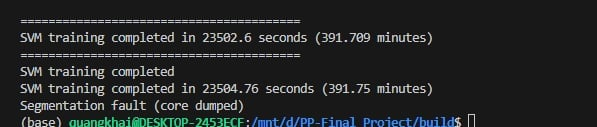



- *Problem:* Training SVM cho GPU autoencoder version lâu và crash luôn session.

- *Solution:* Em thực hiện thử cài đặt ThunderSVM nhưng vẫn gặp vấn đề sau đó xử dụng thư viện mới cuML để có thể đưa ra kết quả nhanh.



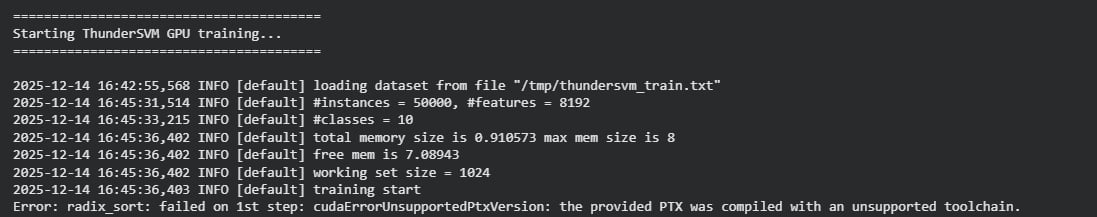

- *Lesson:* Train SVM trên CPU rất chậm khi số lượng feature lớn, cần dùng các thư viện GPU phù hợp giúp tối ưu thời gian.

# **5. Conclusion and Future Work**


## **5.1 Project Summary**

**a. Pipeline tải và tiền xử lý dữ liệu hoàn chỉnh**

- Đọc trực tiếp file nhị phân CIFAR-10 (1 byte nhãn + 3072 byte pixel/ảnh)
- Chuẩn hóa pixel từ uint8 [0-255] sang float [0-1]
- Load dữ liệu theo định dạng NCHW, triển khai `shuffle()` và `load_batch()`
- Xử lý ổn định 50.000 ảnh train và 10.000 ảnh test

**b. Triển khai hoàn chỉnh tất cả các lớp trên CPU**

- **Các layers**: Conv2D (forward/backward, Xavier/He init, SGD), ReLU, MaxPool, Upsample
- **Autoencoder**: Encoder nén 32×32×3 → 8.192 chiều, Decoder tái tạo, Loss MSE
- **Training loop**: Forward/backward pass, weight update, theo dõi loss/time/memory

**c. Đo lường hiệu năng baseline**

- **Thời gian**: CPU baseline ~3,927,270s (ước tính), feature extraction 756.79s (500 ảnh)
- **Độ chính xác**: Test 32%, Train 59.8% (với 500 mẫu)
- **Validation**: Tất cả layers vượt qua unit tests, làm reference cho GPU implementations

**d. Kết quả tổng thể**

- Pipeline hoàn chỉnh từ data loading đến classification
- CPU baseline tạo nền tảng vững chắc cho các phiên bản GPU
- Đo lường đầy đủ các chỉ số hiệu năng để so sánh với các phiên bản tối ưu
- Chúng em đã đạt được các tiêu chí đề ra ban đầu như sau:
    
    - Thời gian huấn luyện autoencoder 1 epoch (50.000 ảnh train): 179.47s (GPU Opt v2)
    
    - Thời gian trích xuất đặc trưng (50.000 ảnh train + 10.000 ảnh test): 11.34s (Opt V1 - L4 GPU). 

    - Độ chính xác phân loại kiểm thử: 66.70% (Opt V2)
    
    - Tốc độ huấn luyện GPU so với CPU: ~1,095× (Opt V2), ~1,060× (Opt V1), ~426× (Naive).

## **5.2 Key Achievements**


**a. Thời gian training được cải thiện**

- Đạt **1,094.60×** so với CPU baseline (GPU Opt v2)

  - CPU: ~3,927,270 giây → GPU Opt v2: 3,589.32 giây

  - Giảm thời gian từ ~45 ngày xuống ~1 giờ

- Tốc độ tăng tốc qua các phiên bản: Naive (426×) → Opt v1 (1,060×) → Opt v2 (1,095×)

- Feature extraction: Giảm từ 756.79s xuống 26.39s (tăng tốc 28.7×)

**b. Độ chính xác phân loại**

- Đạt **66.70%** trên tập kiểm thử (GPU Opt v2), vượt mục tiêu 60-65%

- Các phiên bản: Naive (63.03%) → Opt v1 (63.97%) → Opt v2 (66.70%)

- Độ chính xác train: 98.66% (Opt v2)

- Cải thiện từ 32% (CPU baseline) lên 66.70% (GPU với toàn bộ dataset)

**c. Tối ưu hóa thành công nhất**

- **GPU Optimized v2** với Kernel Fusion + CUDA Streams + Loop Unrolling
  
  - Độ chính xác cao nhất: 66.70%
  
  - Thời gian training nhanh nhất: 3,589.32 giây
  
  - Feature extraction nhanh nhất: 26.39 giây

**d. Kỹ năng kỹ thuật đã thành thạo**

- **Lập trình CUDA**: Viết và tối ưu kernels, quản lý bộ nhớ GPU, sử dụng Streams

- **Deep Learning**: Triển khai từ đầu các layers (Conv2D, ReLU, MaxPool, Upsample), forward/backward pass, autoencoder

- **Tối ưu hóa**: Phân tích bottlenecks, áp dụng các kỹ thuật tối ưu có hệ thống

- **Pipeline ML**: Xử lý dữ liệu CIFAR-10, validation/testing, tích hợp autoencoder với SVM

## **5.3 Project Limitations**


- Ở phiên bản optimized V2, mặc dù hiệu suất tổng thể đã được cải thiện đáng kể nhưng phần backward (đặc biệt là cập nhật trọng số) vẫn chiếm hơn 50% tổng thời gian chạy. Cho thấy nút thắt hiện tại không còn nằm ở forward nữa mà nằm ở khâu tính gradient và update, cần tiếp tục nghiên cứu các hướng tối ưu sâu hơn

- Hiện tại quá trình train autoencoder chiếm phần lớn thời gian của pipeline. Tuy nhiên bản chất của autoencoder có nhiều pha tuần tự và phụ thuộc lẫn nhau (forward → loss → backward theo từng layer), nên việc song song hóa triệt để là rất khó, nên cần nghiên cứu thêm.

- Mặc dù đã đạt độ chính xác như mục tiêu mô hình hiện tại vẫn chưa thể triển khai thực tiễn: độ chính xác 66.70% ở bản Optimized V2 vẫn chưa đủ so với tiêu chuẩn công nghiệp (industry standards) thường kỳ vọng khoảng 80% trở lên. Do đó cần có sự nghiên cứu và tối ưu thêm.

## **5.4 Future Improvements and Extensions**


- Tận dụng thư viện tăng tốc chuẩn công nghiệp: Tích hợp cuDNN/cuBLAS cho Conv2D và các phép toán nền tảng để vừa đảm bảo độ đúng vừa tận dụng tối đa phần cứng GPU, đồng thời so sánh với các bản kernel tự cài đặt.

- Nâng chất lượng feature để tăng accuracy: Thử thay đổi kiến trúc (nhiều tầng hơn, batch norm, skip connections), cải thiện loss/regularization và chiến lược training để nâng độ chính xác phân loại vượt mốc hiện tại (66.70%).

- Mở rộng bài toán và đánh giá: Thử nghiệm trên dataset lớn hơn/khó hơn (CIFAR-100, STL-10).